In [1]:
%load_ext autoreload
%autoreload 2

# Orthogonality of sRNA in mRNA targetting

## Imports

In [2]:
import os
from subprocess import Popen, PIPE, run
import re
from datetime import datetime
import pandas as pd
import logging

from synbio_morpher.srv.io.manage.script_manager import script_preamble
from synbio_morpher.srv.parameter_prediction.IntaRNA.bin.copomus.IntaRNA import IntaRNA
from synbio_morpher.srv.parameter_prediction.simulator import process_raw_stdout
from synbio_morpher.utils.common.setup import prepare_config, expand_config
from synbio_morpher.utils.data.data_format_tools.common import load_json_as_dict
from synbio_morpher.utils.data.data_format_tools.manipulate_fasta import load_seq_from_FASTA
from synbio_morpher.utils.misc.type_handling import flatten_listlike

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data

In [3]:
fn_merged_inter = os.path.join('..', 'data', 'sRNA', 'merged_inter.csv')
# fn_merged_inter = os.path.join('..', 'data', 'sRNA', 'merged_EcoCyc_RNAInter_sRNATarBase.csv')
data = pd.read_csv(fn_merged_inter, index_col=0)
try:
    data = data.drop(columns=['Unnamed: 0', 'level_0'])
except:
    pass

data = data[~data['Sequence 1'].isna()]
data = data[~data['Sequence 2'].isna()]
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

In [4]:
data[data['Interactor 1'] == 'ryhB']['Sequence 1'].unique()

array(['GCGATCAGGAAGACCCTCGCGGAGAACCTGAAAGCACGACATTGCTCACATTGCTTCCAGTATTACTTAGCCAGCCGGGTGCTGGCTTTT'],
      dtype=object)

In [5]:
print(len(data))
nn = np.sum(np.arange(1, len(data)+1)) + len(data)
print('Expected number of species: ', nn)
print('Number of sRNA', data['Interactor 1'].nunique())
print('Number of mRNA', data['Interactor 2'].nunique())
data

378
Expected number of species:  72009
Number of sRNA 46
Number of mRNA 266


,Interactor 1,Interactor 2,ID 1,ID 2,Category 1,Category 2,Regulation,Binding position 1,Binding position 2,Sequence 1,Sequence 2,Source DB,Genome position 1,Genome position 2,Strand 1,Strand 2,Sequence before 1,Sequence before 2,Sequence after 1,Sequence after 2
50,dsrA,dsrB,NCBI:946470,NCBI:946468,sRNA,mRNA,NaN,NaN,NaN,AACACATCAGATTTCCTGGTGTAACGAATTTTTTAAGTGCTTCTTG...,TAAATGNAAACAAGTTTTATTTTTATCATCAGAACATTCTAATAAA...,RNAInter,NaN,NaN,NaN,NaN,ttcatcaccttatccgcaatttttttcgctgacaagaaaatattcg...,atcgttttcctcctgtggctttgtgccagtgtagaacaatttcgtt...,cgtgaggtcagcgtcgatgtcgatgccctgctggcggcgatcaatg...,NaN
53,dsrA,ilvH,NCBI:946470,NCBI:947267,sRNA,mRNA,NaN,NaN,NaN,AACACATCAGATTTCCTGGTGTAACGAATTTTTTAAGTGCTTCTTG...,ATTCGCCACAACAAGGACAGGAAGGTTCGGCGCAAGGAGCCCAAGA...,RNAInter,NaN,NaN,NaN,NaN,ttcatcaccttatccgcaatttttttcgctgacaagaaaatattcg...,ATTCGCCACAACAAGGACAGGAAGGTTCGGCGCAAGGAGCCCAAGA...,cgtgaggtcagcgtcgatgtcgatgccctgctggcggcgatcaatg...,ATTCGCCACAACAAGGACAGGAAGGTTCGGCGCAAGGAGCCCAAGA...
74,oxyS,fhlA,NCBI:2847701,NCBI:947181,sRNA,mRNA,NaN,NaN,NaN,GAAACGGAGCGGCACCTCTTTTAACCCTTGAAGTCACTGCCCGTTT...,CACCAGATTGCCAAGCTGATGGTCGAGCTGTCCAAATCCCAGGATG...,RNAInter,NaN,NaN,NaN,NaN,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,CACCAGATTGCCAAGCTGATGGTCGAGCTGTCCAAATCCCAGGATG...,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,CACCAGATTGCCAAGCTGATGGTCGAGCTGTCCAAATCCCAGGATG...
138,sgrS,hfq,NCBI:4056038,NCBI:948689,sRNA,mRNA,NaN,NaN,NaN,GATGAAGCAAGGGGGTGCCCCATGCGTCAGTTTTATCAGCACTATT...,ATGGCTAAGGGGCAATCTTTACAAGATCCGTTCCTGAACGCACTGC...,RNAInter,NaN,NaN,NaN,NaN,ttgagcagggtgcgcatatgacgacgcgagcagctcaataacgctg...,cgaagcggcagataacctggctgcgtggttgggaaggggttcactg...,ttattctcgccgcgctaaaaagggaacgtatgatctggataatgac...,aaggtttcgggctgtttttttacacggggagccagcgatcctgcgt...
230,oxyS,nusG,NCBI:2847701,NCBI:948485,sRNA,mRNA,NaN,NaN,NaN,GAAACGGAGCGGCACCTCTTTTAACCCTTGAAGTCACTGCCCGTTT...,ATGTCTGAAGCTCCTAAAAAGCGCTGGTACGTCGTTCAGGCGTTTT...,RNAInter,NaN,NaN,NaN,NaN,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,cgacaaaaggtaaagctaccgttgcttttgcccgtgaagcgcgtac...,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,aacccagcgatcaaaaaagcggcgatttaatcgttgcacaaggcgt...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,ryhB,msrA,"chromosome:NC_000913.3, Gene ID:2847761","chromosome:NC_000913.3, Gene ID:948734",sRNA,mRNA,No Interaction,['NA'],['NA'],GCGATCAGGAAGACCCTCGCGGAGAACCTGAAAGCACGACATTGCT...,ATGAGTTTATTTGATAAAAAGCATCTGGTTTCCCCCGCCGATGCCC...,sRNATarBase,3580927..3581016,4441538..4442176,reverse,reverse,TTTGAGAGCGTCTCTGTCCCTCGTTTTGCGGTTAAGCCGCATCCAT...,atggtgtcgctctcccgaaaatcggtcattggggttaaggttgtaa...,TTTGAGAGCGTCTCTGTCCCTCGTTTTGCGGTTAAGCCGCATCCAT...,aggtactgtaaagccgccagagggttaaaattcagacagctgaaaa...
759,gcvB,hdeA,"chromosome:NC_000913.3, Gene ID:2847720","chromosome:NC_000913.3, Gene ID:948025",trans-encoded antisense RNA,mRNA,Induction,['NA'],['NA'],ACTTCCTGAGCCGGAACGAAAAGTTTTATCGGAATGCGTGTTCTGG...,ATGAAAAAAGTATTAGGCGTTATTCTTGGTGGTCTGCTTCTTCTGC...,sRNATarBase,2942696..2942901,3656408..3656740,forward,reverse,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,atcgtaatatcctcaactataaagtgaaagagccgtcacgaatcaa...,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,gccaacgcagattgtgcgttcaccagtgacaaagccgctacagcgc...
760,gcvB,hdeB,"chromosome:NC_000913.3, Gene ID:2847720","chromosome:NC_000913.3, Gene ID:948026",trans-encoded antisense RNA,mRNA,Induction,['NA'],['NA'],ACTTCCTGAGCCGGAACGAAAAGTTTTATCGGAATGCGTGTTCTGG...,ATGAATATTTCATCTCTCCGTAAAGCGTTTATTTTTATGGGCGCTG...,sRNATarBase,2942696..2942901,3655966..3656292,forward,reverse,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,attttgtaacccattcaatatagagattatatatgaacaggaggaa...,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,cataaacagggcgcttcccatgccaattaatacatgtgtgcgtaac...
761,Esr41,fliC,"chromosome:NC_002695.1, Gene ID:","chromosome:NC_002695.1, Gene ID:",trans-encoded antisense RNA,mRNA,Induction,['NA'],['NA'],GATGCTCTAGGCATCACATTTTCTCCATGGGGTATTCCCTCCGCCG...,ATGGCACAAGTCATTAATACCAACAGCCTCTCGCTGATCACTCAAA...,sR

# Get mRNAs and sRNAs

In [6]:
data['Category 1'].unique()

array(['sRNA', 'pseudo', 'trans-encoded antisense RNA', 'Protein'],
      dtype=object)

In [7]:
data['Category 2'].unique()

array(['mRNA', 'sRNA'], dtype=object)

In [8]:
pattern = r'\s*\([^)]*\)'
for i in [1, 2]:
    data[f'Binding position {i}'] = list(map(lambda raw: flatten_listlike(
        [[[int(re.sub(pattern, '', bp)) for bp in bps.split('..')]
          for bps in re.sub(pattern, '', par).split('; ')] for par in raw if par.split('..')[0].strip('-').isnumeric()]), data[f'Binding position {i}'].apply(str).str.split("'")))

In [9]:
# srnas = list(set(data[data['Category 1'] != 'mRNA']['Interactor 1'].to_list() + data[data['Category 2'] != 'mRNA']['Interactor 2'].to_list()))
# mrnas = list(set(data[data['Category 1'] == 'mRNA']['Interactor 1'].to_list() + data[data['Category 2'] == 'mRNA']['Interactor 2'].to_list()))

srnas, mrnas = {}, {}
filt_srna1 = data['Category 1'].isin(['sRNA', 'trans-encoded antisense RNA', 'protein binding small RNA'])
filt_srna2 = data['Category 2'].isin(['sRNA', 'trans-encoded antisense RNA', 'protein binding small RNA']) & (~data['Category 1'].isin(['Protein']))
for i in [1, 2]:
    filt = filt_srna1 if i == 1 else filt_srna2
    for s in data[f'Interactor {i}'].unique():
        seq = data[data[f'Interactor {i}'] == s][f'Sequence {i}'].iloc[0]
        offset = data[data[f'Interactor {i}'] == s][f'Binding position {i}'].iloc[0]
        if offset:
            offset = np.min(offset)
            if offset < 0: 
                seq = data[data[f'Interactor {i}'] == s][f'Sequence before {i}'].iloc[0] + seq
        if s in data[data[f'Category {i}'] == 'mRNA'][f'Interactor {i}'].unique():
            mrnas[s] = seq.replace('T', 'U').replace('t', 'u')
        elif s in data[filt][f'Interactor {i}'].unique():
            srnas[s] = seq.replace('T', 'U').replace('t', 'u')
            

## Check that no sRNA's are overlapping with mRNAs

In [10]:
len(srnas) == (len(set(srnas.keys()) - set(mrnas.keys())))


True

Add the synthetic ChiX that Scott made:

In [11]:
fn_mutations = os.path.join('data', 'scott_mutations.fasta')
muts = load_seq_from_FASTA(fn_mutations, as_type='dict')


In [12]:
muts.keys()

dict_keys(['Syn_ChiX_20-D', 'MutagenesisVariant_1', 'MutagenesisVariant_2', 'MutagenesisVariant_3', 'MutagenesisVariant_4', 'MutagenesisVariant_5', 'MutagenesisVariant_6', 'MutagenesisVariant_7', 'MutagenesisVariant_8', 'MutagenesisVariant_9', 'MutagenesisVariant_10', 'MutagenesisVariant_11', 'MutagenesisVariant_12', 'MutagenesisVariant_13', 'MutagenesisVariant_14', 'MutagenesisVariant_15', 'MutagenesisVariant_16', 'MutagenesisVariant_17', 'MutagenesisVariant_18', 'MutagenesisVariant_19', 'MutagenesisVariant_20', 'MutagenesisVariant_21', 'MutagenesisVariant_22', 'MutagenesisVariant_23', 'MutagenesisVariant_24', 'MutagenesisVariant_25', 'MutagenesisVariant_26', 'MutagenesisVariant_27', 'MutagenesisVariant_28', 'MutagenesisVariant_29', 'MutagenesisVariant_30', 'MutagenesisVariant_31', 'MutagenesisVariant_32', 'MutagenesisVariant_33', 'MutagenesisVariant_34', 'MutagenesisVariant_35', 'MutagenesisVariant_36', 'MutagenesisVariant_37', 'MutagenesisVariant_38', 'MutagenesisVariant_39', 'Mutag

In [13]:
srnas['Syn_ChiX_20-D'] = muts['Syn_ChiX_20-D']

Make config to run IntaRNA simulations.

In [14]:
config = {
    "experiment": {
        "purpose": "tests",
        "no_visualisations": False,
        "no_numerical": False,
        "debug_mode": False
    },
    "data": {},
    "system_type": "RNA",
    "include_prod_deg": False,
    "interaction_simulator": {
        "name": "IntaRNA",
        "postprocess": True,
        "simulator_kwargs": {
            # "outcsvcols": "id1, id2, E, E_norm, bpList, hybridDPfull, seedPu1, seedPu2, seedStart1, seedStart2, seedEnd1, seedEnd2",
            "outcsvcols": "id1, id2, E, E_norm, subseqDB, Pu1, Pu2",
            "threads": 12,
            "n": 1,
            "raw_stdout": True
        }
    },
    "molecular_params_factor": 1,
    "molecular_params": {
        "avg_mRNA_per_cell": 100,
        "cell_doubling_time": 1200,
        "creation_rate": 2.35,
        "starting_copynumbers": 200,
        "degradation_rate": 0.01175,
        "association_binding_rate": 1000000
    }
}

In [15]:
data_writer = None
config, data_writer = script_preamble(config, data_writer)
config_file = expand_config(config=config)
config_file = prepare_config(config_file)

## Create circuits

In [16]:
len(srnas) * len(mrnas)

11266

In [17]:

def simulate_IntaRNA_local(query: dict,
                           targets: dict,
                           sim_kwargs={}):
    fn1 = data_writer.output(data=query, out_type='fasta', out_name='query', byseq=True, return_path=True)
    fn2 = data_writer.output(data=targets, out_type='fasta', out_name='targets', byseq=True, return_path=True)
    sim_kwargs['query'] = fn1
    sim_kwargs['target'] = fn2
    
    def run(query: str, target: str, qidxpos0: int, tidxpos0: int, outcsvcols: str, threads: int, n: int = 1,
            param_file: str = '', extra_params: list = [], raw_stdout: bool = False):
        p = Popen(['IntaRNA', '-q', query, '-t', target,
                    '--outMode=C', f'--outcsvcols={outcsvcols}',
                    f'--qIdxPos0={qidxpos0}',
                    f'--tIdxPos0={tidxpos0}',
                    f'--outNumber={n}',
                    f'--threads={threads}', param_file]
                    + extra_params, stdout=PIPE, stderr=PIPE, universal_newlines=True)
        stdout, stderr = p.communicate()
        return process_raw_stdout(stdout)
    
    return run(**sim_kwargs)

In [18]:
run_intarna = False

if run_intarna:
    sim_data = {}


    for s, sseq in srnas.items():
        sim_data[s] = {}
        t = datetime.now()

        sim_data[s] = simulate_IntaRNA_local(query={s: sseq},
                                            targets=mrnas,
                                            sim_kwargs=config_file['interaction_simulator']['simulator_kwargs'])
        # print('Finished ', s, ' in ', (datetime.now() - t).total_seconds(), ' s')
        logging.warning('Finished ', s, ' in ', (datetime.now() - t).total_seconds(), ' s')

        data_writer.output(data=sim_data, out_type='json',
                        out_name='inter_data_raw', overwrite=True)

In [19]:
print(data_writer.write_dir)

./data/tests/2026_04_03_082858


# Load simulation results

In [20]:
# fn = './data/05_orthogonality_mRNA_official/2023_11_08_145023/inter_data_raw.json'
# fn = './data/05_orthogonality_mRNA_official/2023_11_21_095238/inter_data_raw.json'
# fn = './data/05_orthogonality_mRNA_official/2023_12_04_120211/inter_data_raw.json'
fn = './data/05_orthogonality_mRNA_official/2024_01_04_105924/inter_data_raw.json'

sim_data_l = load_json_as_dict(fn)

In [21]:
len(srnas)

43

In [22]:
len(sim_data_l)

234

In [23]:
sim_data_l = {k: v for k, v in sim_data_l.items() if k in srnas.keys()}

In [24]:
k1 = list(sim_data_l.keys())[0]
k2 = list(sim_data_l[k1].keys())[0]
header = list(sim_data_l[k1][k2].keys())
header

['id1', 'id2', 'E', 'E_norm', 'subseqDB', 'Pu1', 'Pu2']

In [25]:
sim_data_l[k1][k2]

{'id1': 'ecnB',
 'id2': 'dsrA',
 'E': '-2.56',
 'E_norm': '-0.270718',
 'subseqDB': '39GGUGCUU&35AAGUGCU',
 'Pu1': '0.0835363',
 'Pu2': '0.0745675'}

In [26]:
default_vals = {
    'id1': '', 'id2': '', 'E': 0.0, 'E_norm': 0.0, 'subseqDB': '', 'bpList': '', 'hybridDPfull': '', 'Pu1': 0.0, 'Pu2': 0.0, 'seedPu1': '', 'seedPu2': '', 'seedStart1': '', 'seedStart2': '', 'seedEnd1': '', 'seedEnd2': ''
}

Need to add zeros back in, since IntaRNA just excludes runs where the binding energy is zero kcal.

In [27]:
mrnas_set = set(mrnas.keys())
for s, v in sim_data_l.items():
    mrnas_set = set(list(mrnas_set) + list(v.keys()))
for s, v in sim_data_l.items():
    if len(mrnas_set) != len(mrnas):
        diffs = mrnas_set - set(v.keys())
        for d in diffs:
            sim_data_l[s][d] = default_vals
        

In [28]:
len(mrnas)

262

In [29]:
list(sim_data_l.keys())[-1]

'Syn_ChiX_20-D'

In [30]:
sim_data_l.keys()

dict_keys(['dsrA', 'oxyS', 'sgrS', 'ryhB', 'sdsR', 'micF', 'micC', 'istR', 'omrA', 'omrB', 'rprA', 'rseX', 'rybB', 'Spot_42', 'cyaR', 'dicF', 'gadY', 'symR', 'sokB', 'sokC', 'gcvB', 'rdlD', 'fnrS', 'sibC', 'arcZ', 'sibB', 'mgrR', 'chiX', 'mcaS', 'ohsC', 'OrzO', 'sibD', 'sibE', 'sibA', 'IpeX', 'rdlA', 'rdlB', 'rdlC', 'arrS', 'mntS', 'AfaR', 'Esr41', 'Syn_ChiX_20-D'])

In [31]:
# This a protein
# srnas['rpoD']

In [32]:
mrnas['gpmA']

'UCCCCCGUGUAGAUCAGGUCGAUGAGUCACCGCGUUCCCACGGGUGACCGUGGCGGUGGCUUCGUUGGUGGCCUACCGUGGGGACACCCACAGGACGCUCUAAUACAGACAUGGUGCGAAGAGUCUAUUGAGCUAGUUGGUAGUCUCCGGCCCCUGAAUGCGGCUAAUCCUAACUGCGGAGCAUGCACCCACAAGCCAGUGGGUAGCGUGUCGUAACGGGCAACUCUGCAGCGGAACCGACUACUUUGGGUGACCGUGUUUCUCUUUAUUCUCUCAUUGGCUGCUUAUGGUGACAAUAUGGCUGUAACUAAGCUGGUUCUGGUUCGUCAUGGCGAAAGUCAGUGGAACAAAGAAAACCGUUUCACCGGUUGGUACGACGUGGAUCUGUCUGAGAAAGGCGUAAGCGAAGCAAAAGCAGCAGGUAAGCUGCUGAAAGAGGAAGGUUACAGCUUUGACUUUGCUUACACUUCUGUGCUGAAACGCGCUAUCCAUACCCUGUGGAAUGUGCUGGACGAACUGGAUCAGGCAUGGCUGCCCGUUGAGAAAUCCUGGAAACUGAACGAACGUCACUACGGUGCGUUGCAGGGUCUGAACAAAGCGGAAACUGCUGAAAAGUAUGGCGACGAGCAGGUGAAACAGUGGCGUCGUGGUUUUGCAGUGACUCCGCCGGAACUGACUAAAGAUGAUGAGCGUUAUCCGGGUCACGAUCCGCGUUACGCGAAACUGAGCGAGAAAGAACUGCCGCUGACGGAAAGCCUGGCGCUGACCAUUGACCGCGUGAUCCCUUACUGGAAUGAAACUAUUCUGCCGCGUAUGAAGAGCGGUGAGCGCGUGAUCAUCGCUGCACACGGUAACUCUUUACGUGCGCUGGUGAAAUAUCUUGAUAACAUGAGCGAAGAAGAGAUUCUUGAGCUUAAUAUCCCGACUGGCGUGCCGCUGGUGUAUGAGUUCGACGAGAAUUUCAAACCGCUGAAACGCUAUUAUCUGGGUAAUGCUGAC

## Create IntaRNA variable dataframes

In [33]:
energies = pd.DataFrame(data=np.array([[float(vv['E']) for vv in v.values()] for v in sim_data_l.values()]).T,
                        columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))
energies_norm = pd.DataFrame(data=np.array([[float(vv['E_norm']) for vv in v.values()] for v in sim_data_l.values()]).T,
                             columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))

### Energy cluster

/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 2100x2700 with 0 Axes>

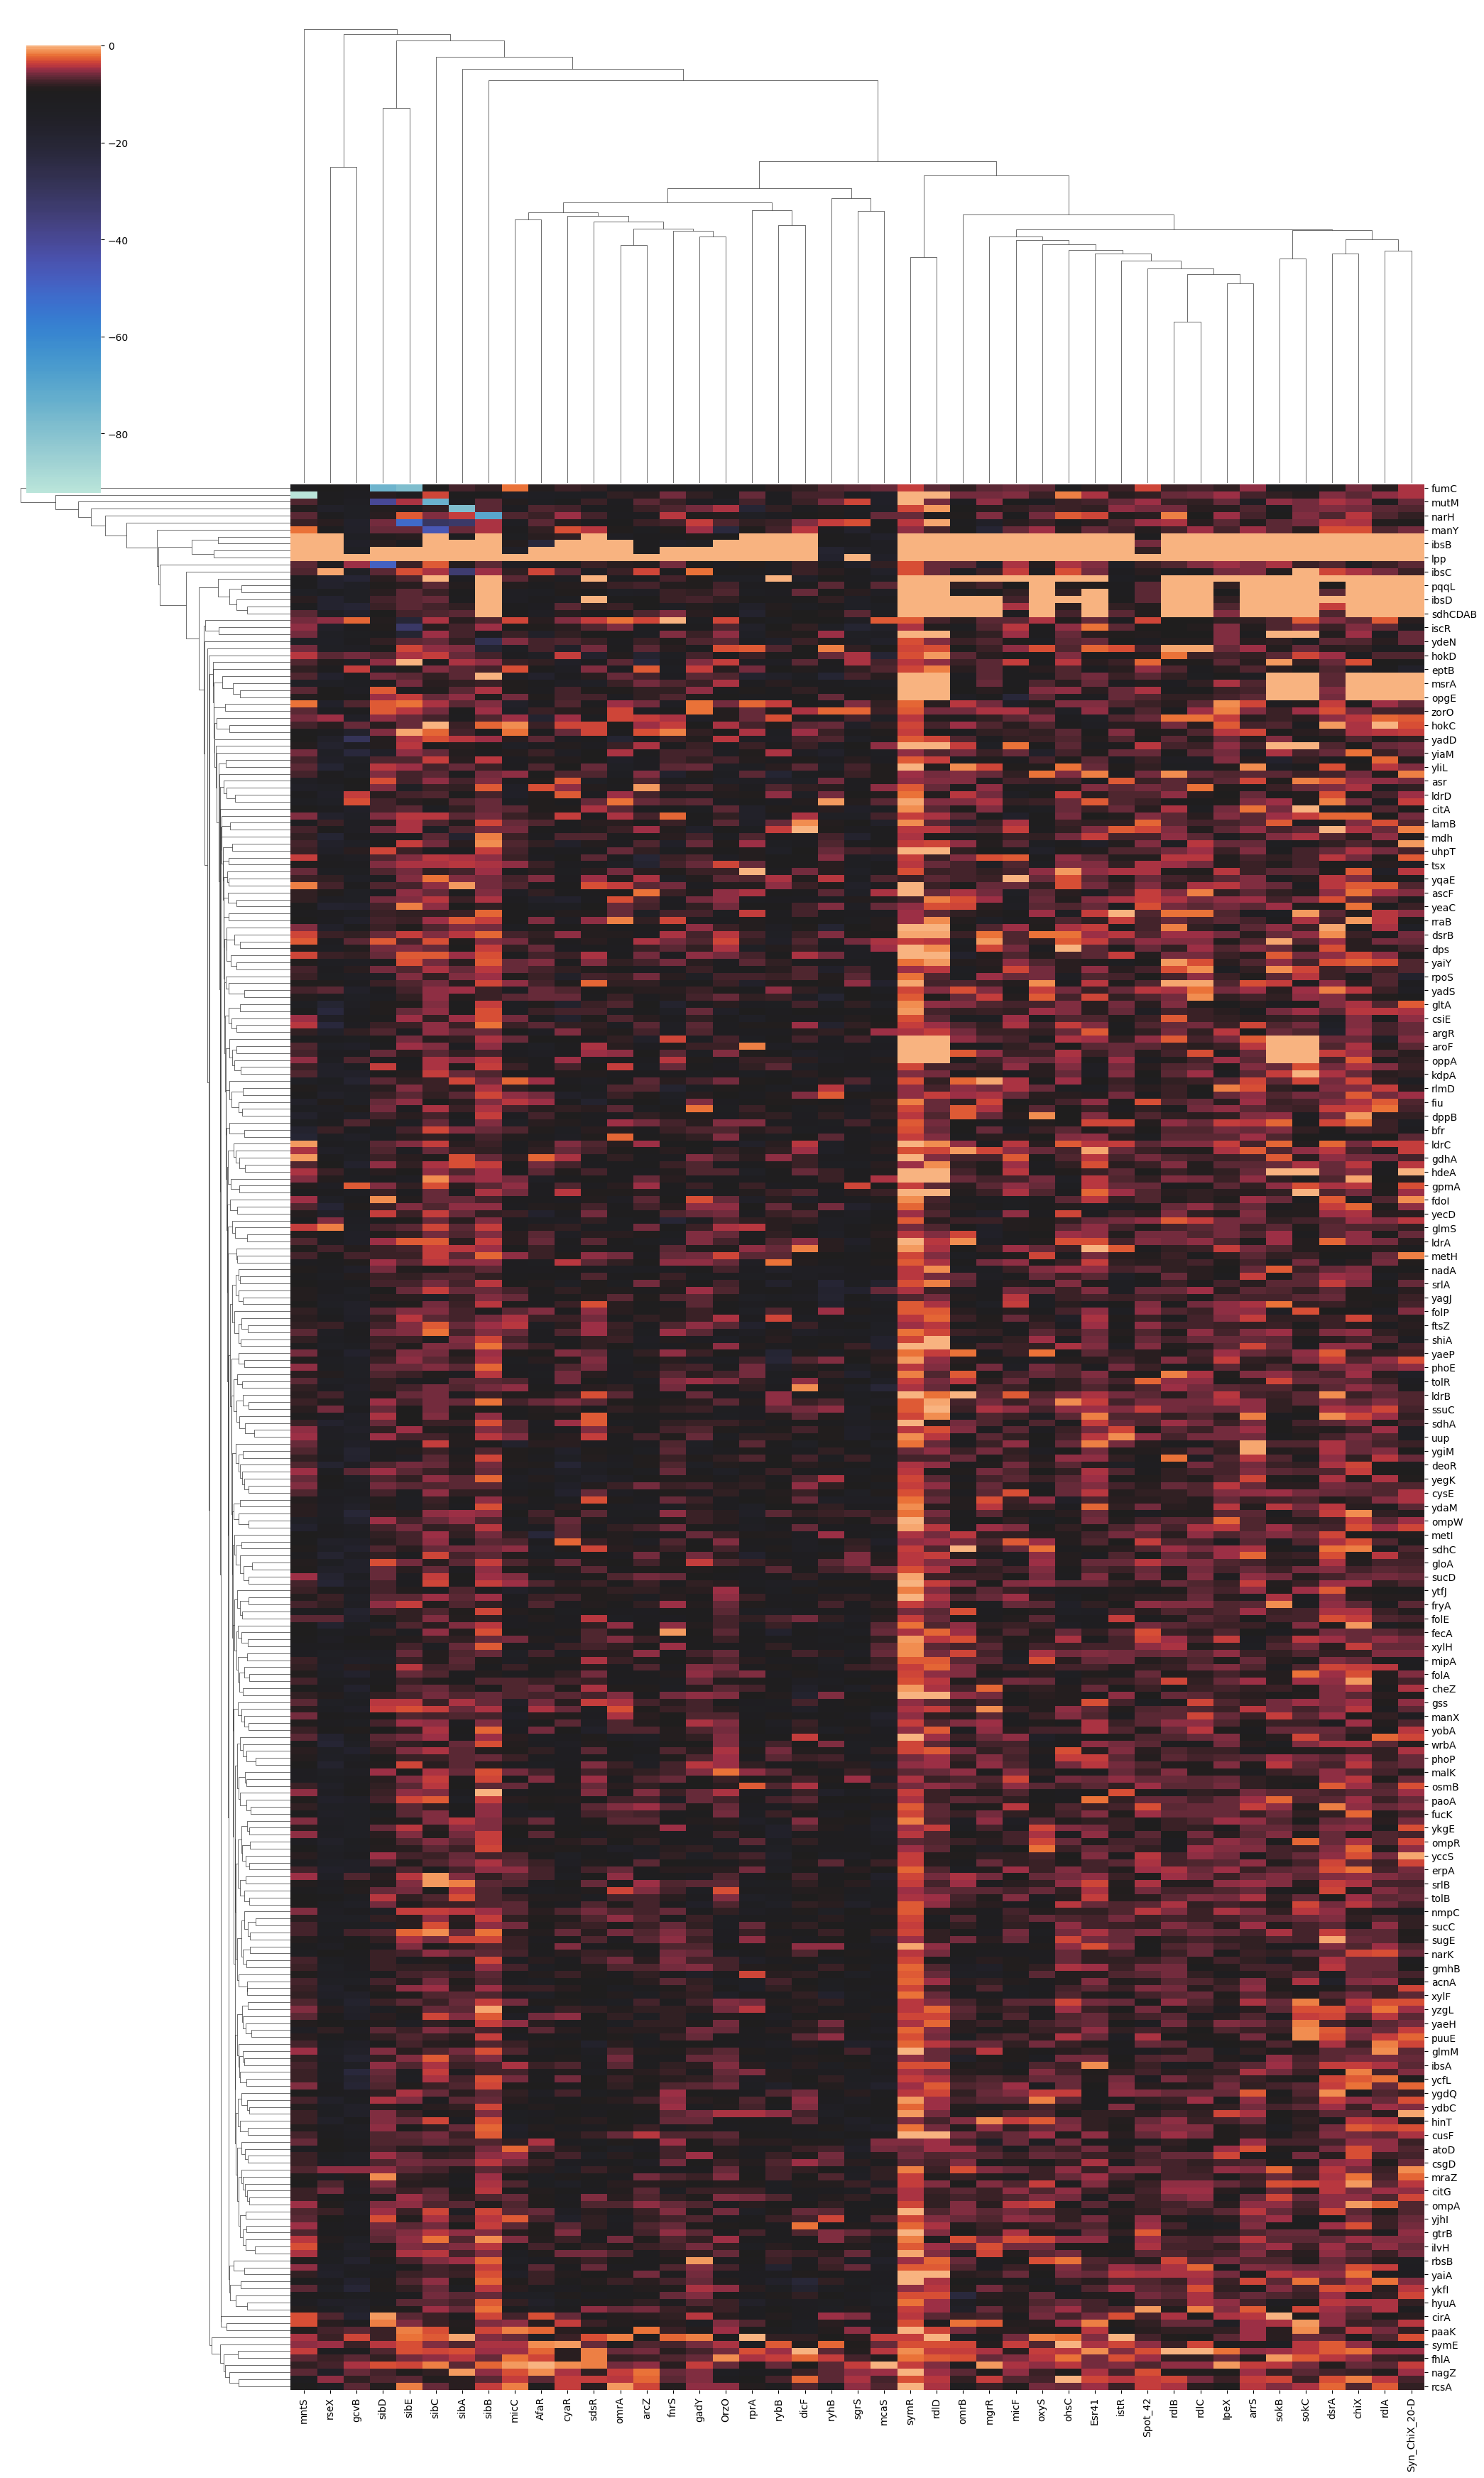

In [34]:
fig = plt.figure(figsize=(21, 27))
center = -10
emin = energies.min().min()
emax = energies.max().max()
total_colors = 100
n_colors_low = int(total_colors * (np.abs(emin - center) / (emax - emin)))
n_colors_high = int(total_colors * (np.abs(emax - center) / (emax - emin)))
custom_palette_clust = sns.blend_palette(
    sns.color_palette('icefire', n_colors=n_colors_low*2).as_hex()[:n_colors_low]
    + sns.color_palette('icefire', n_colors=n_colors_high*2).as_hex()[n_colors_high:],
    as_cmap=True)
g_clust = sns.clustermap(energies, figsize=(21, 35), cmap=custom_palette_clust) # Spectral, cubehelix, vlag
# plt.title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal)')

plt.savefig('data/figs/mRNA_official_energies_cluster.jpg')

### Energy heatmap

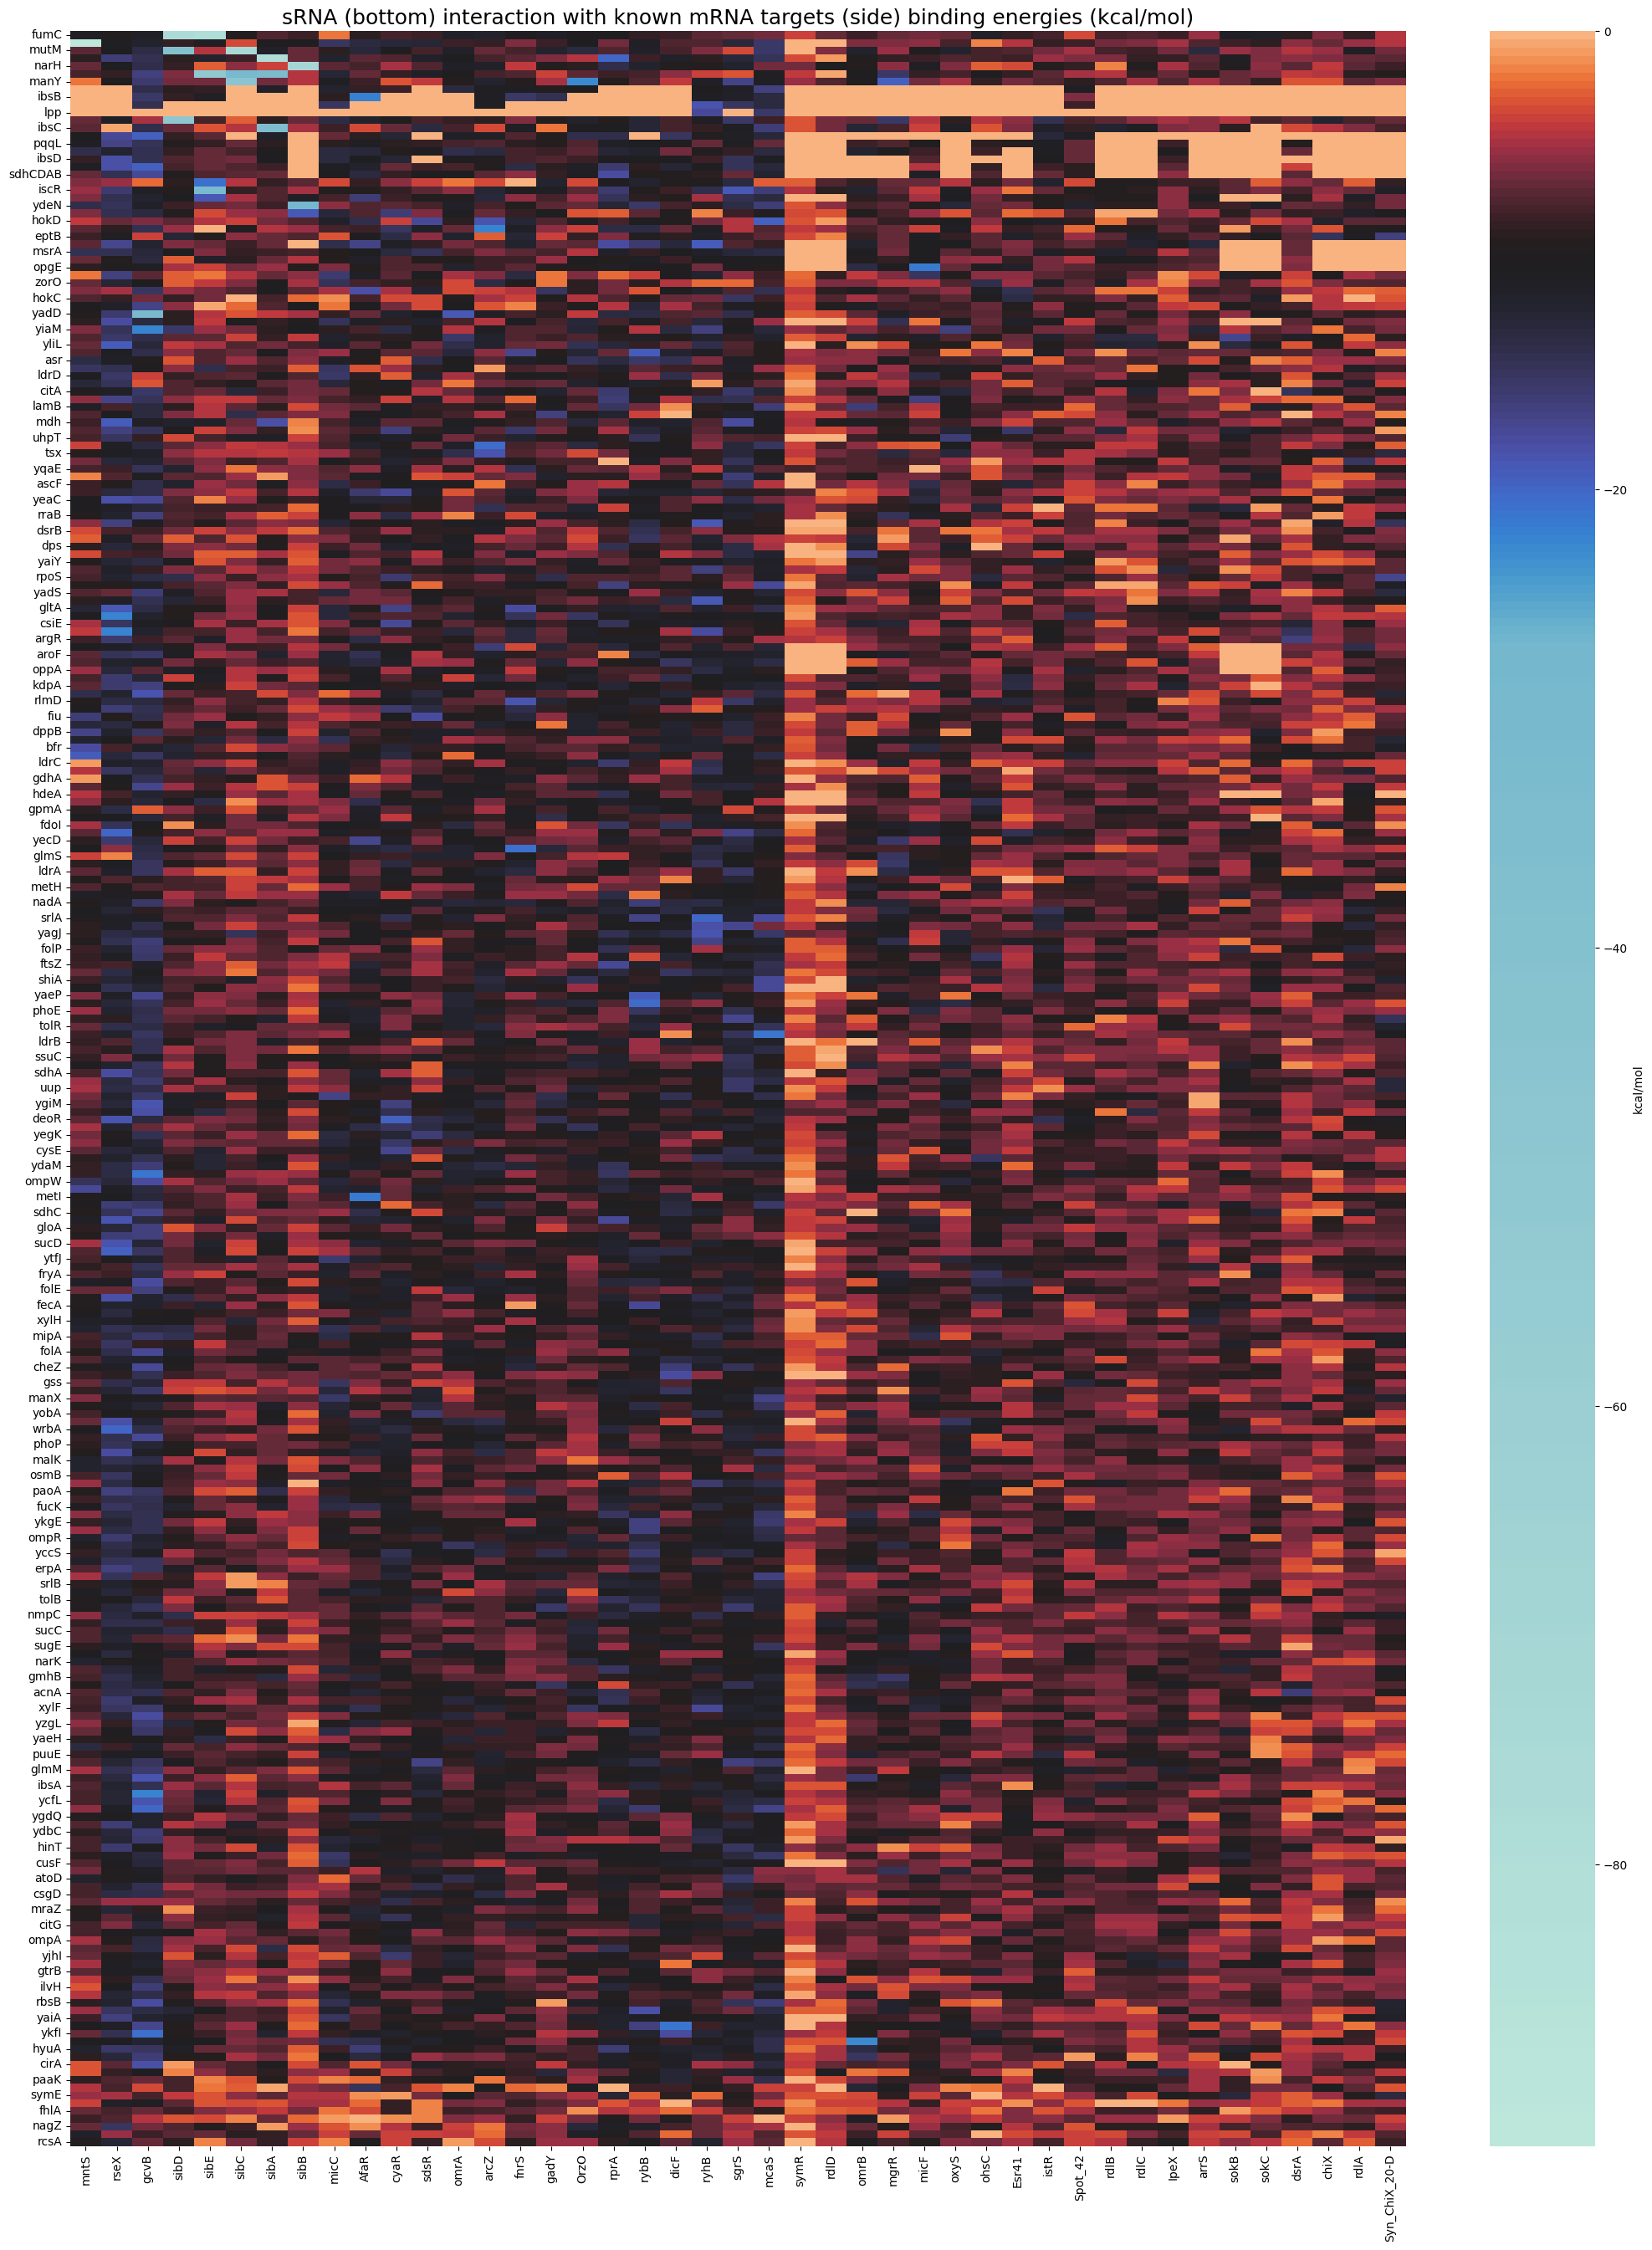

In [80]:
fig = plt.figure(figsize=(21, 27))
center = -10
taper = -30
taper_prop = 0.2
emin = energies.min().min()
emax = energies.max().max()
total_colors = 100
n_colors_low = int(total_colors * (np.abs(emin - taper) / (emax - emin)))
n_colors_med = int(total_colors * (np.abs(taper - center) / (emax - emin)))
n_colors_high = int(total_colors * (np.abs(emax - center) / (emax - emin)))
custom_palette_clust = sns.blend_palette(
    sns.color_palette('icefire', n_colors=int(n_colors_low*2/taper_prop)).as_hex()[:n_colors_low]
    + sns.color_palette('icefire', n_colors=n_colors_med*2).as_hex()[int(n_colors_med*taper_prop):n_colors_med]
    + sns.color_palette('icefire', n_colors=n_colors_high*2).as_hex()[n_colors_high:],
    as_cmap=True)
sns.heatmap(energies.iloc[g_clust.dendrogram_row.reordered_ind][energies.columns[g_clust.dendrogram_col.reordered_ind]], 
            cmap=custom_palette_clust, cbar_kws={'label': 'kcal/mol'}) # Spectral, cubehelix, vlag
plt.title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal/mol)', fontsize=18)

plt.tight_layout()
plt.savefig('data/figs/mRNA_official_energies.jpg', dpi=300, bbox_inches='tight')

Same but on log scale

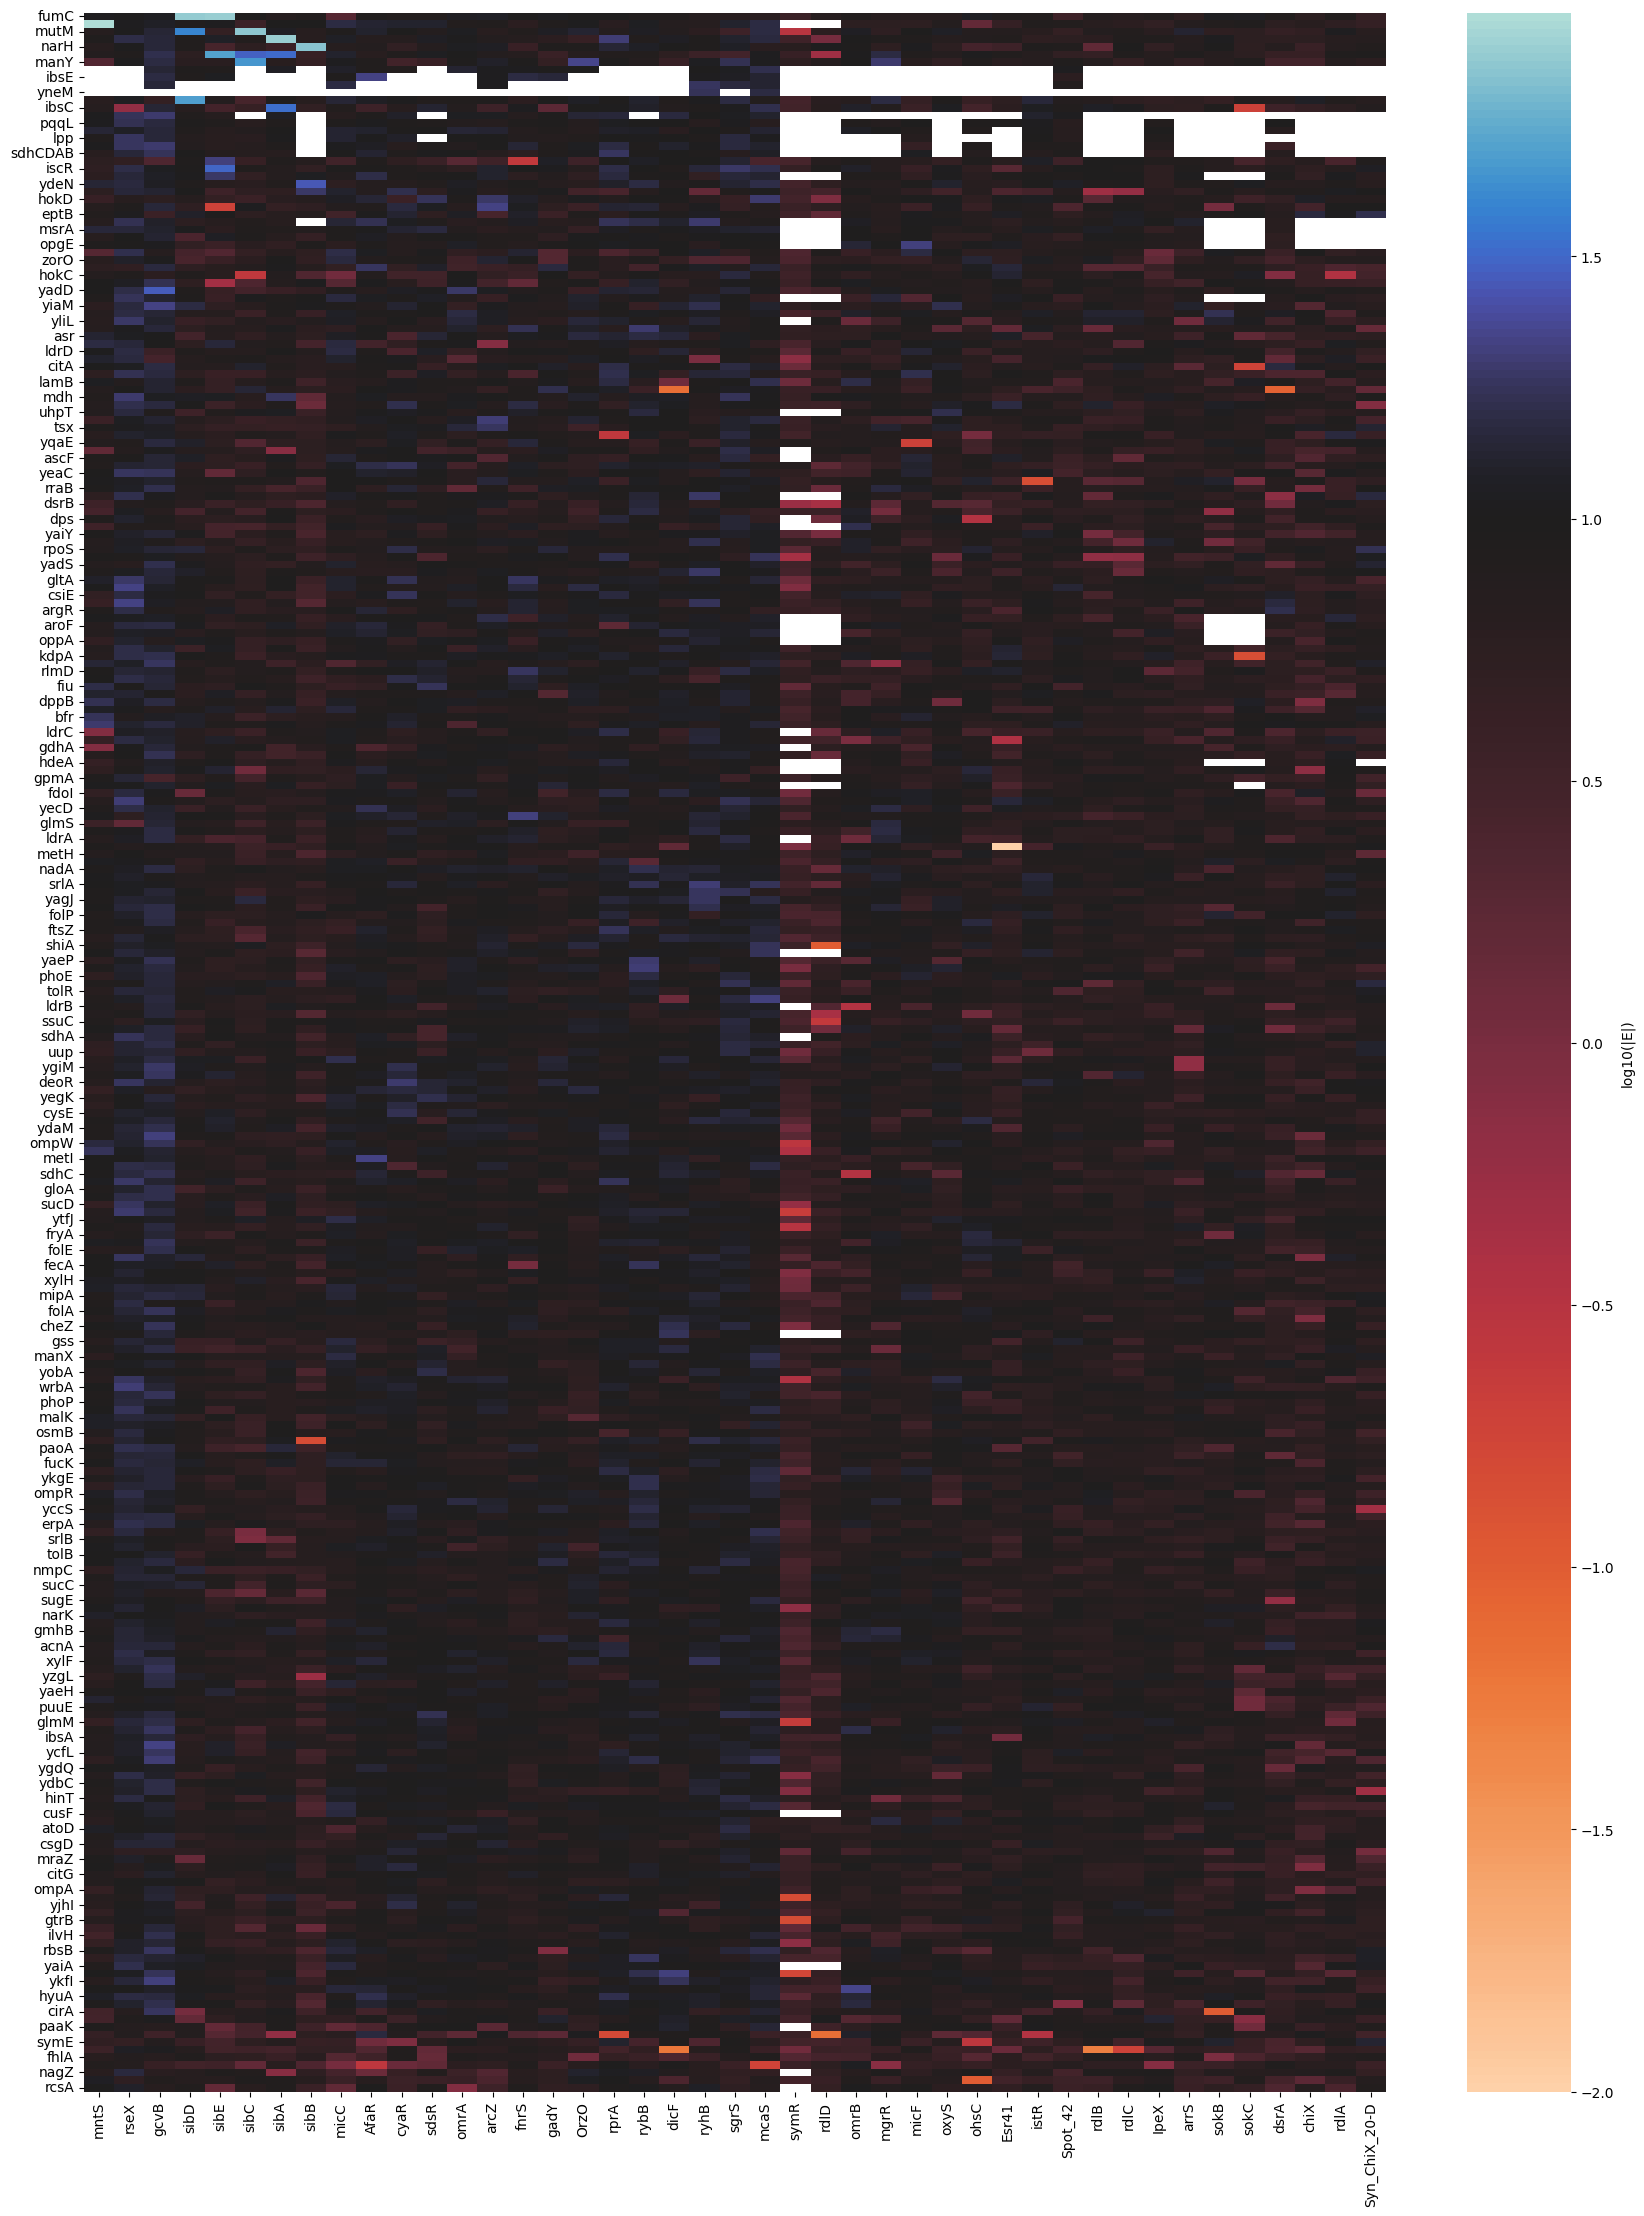

In [ ]:
fig = plt.figure(figsize=(21, 27))

energies_log = energies.apply(lambda x: np.where(x == 0, np.nan, np.abs(x))).apply(np.log10) #.sort_index()
energies_log = energies_log[energies_log.columns[g_clust.dendrogram_col.reordered_ind]]
energies_log = energies_log.iloc[g_clust.dendrogram_row.reordered_ind]

center = np.log10(10)
emin = energies_log.min().min()
emax = energies_log.max().max()
total_colors = 100
n_colors_low = int(total_colors * (np.abs(emin - center) / (emax - emin)))
n_colors_high = int(total_colors * (np.abs(emax - center) / (emax - emin)))
custom_palette = sns.blend_palette(
    sns.color_palette('icefire_r', n_colors=n_colors_low*2).as_hex()[:n_colors_low]
    + sns.color_palette('icefire_r', n_colors=n_colors_high*2).as_hex()[n_colors_high:],
    as_cmap=True)
sns.heatmap(energies_log, cmap=custom_palette,
            cbar_kws={'label': 'log10(|E|)'}) # Spectral, cubehelix, vlag
# plt.title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal)')

plt.savefig('data/figs/mRNA_official_energies_cluster_log10.jpg')

### Energy norm cluster

/home/wadh6511/Kode/env_evo/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/wadh6511/Kode/env_evo/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 2400x2700 with 0 Axes>

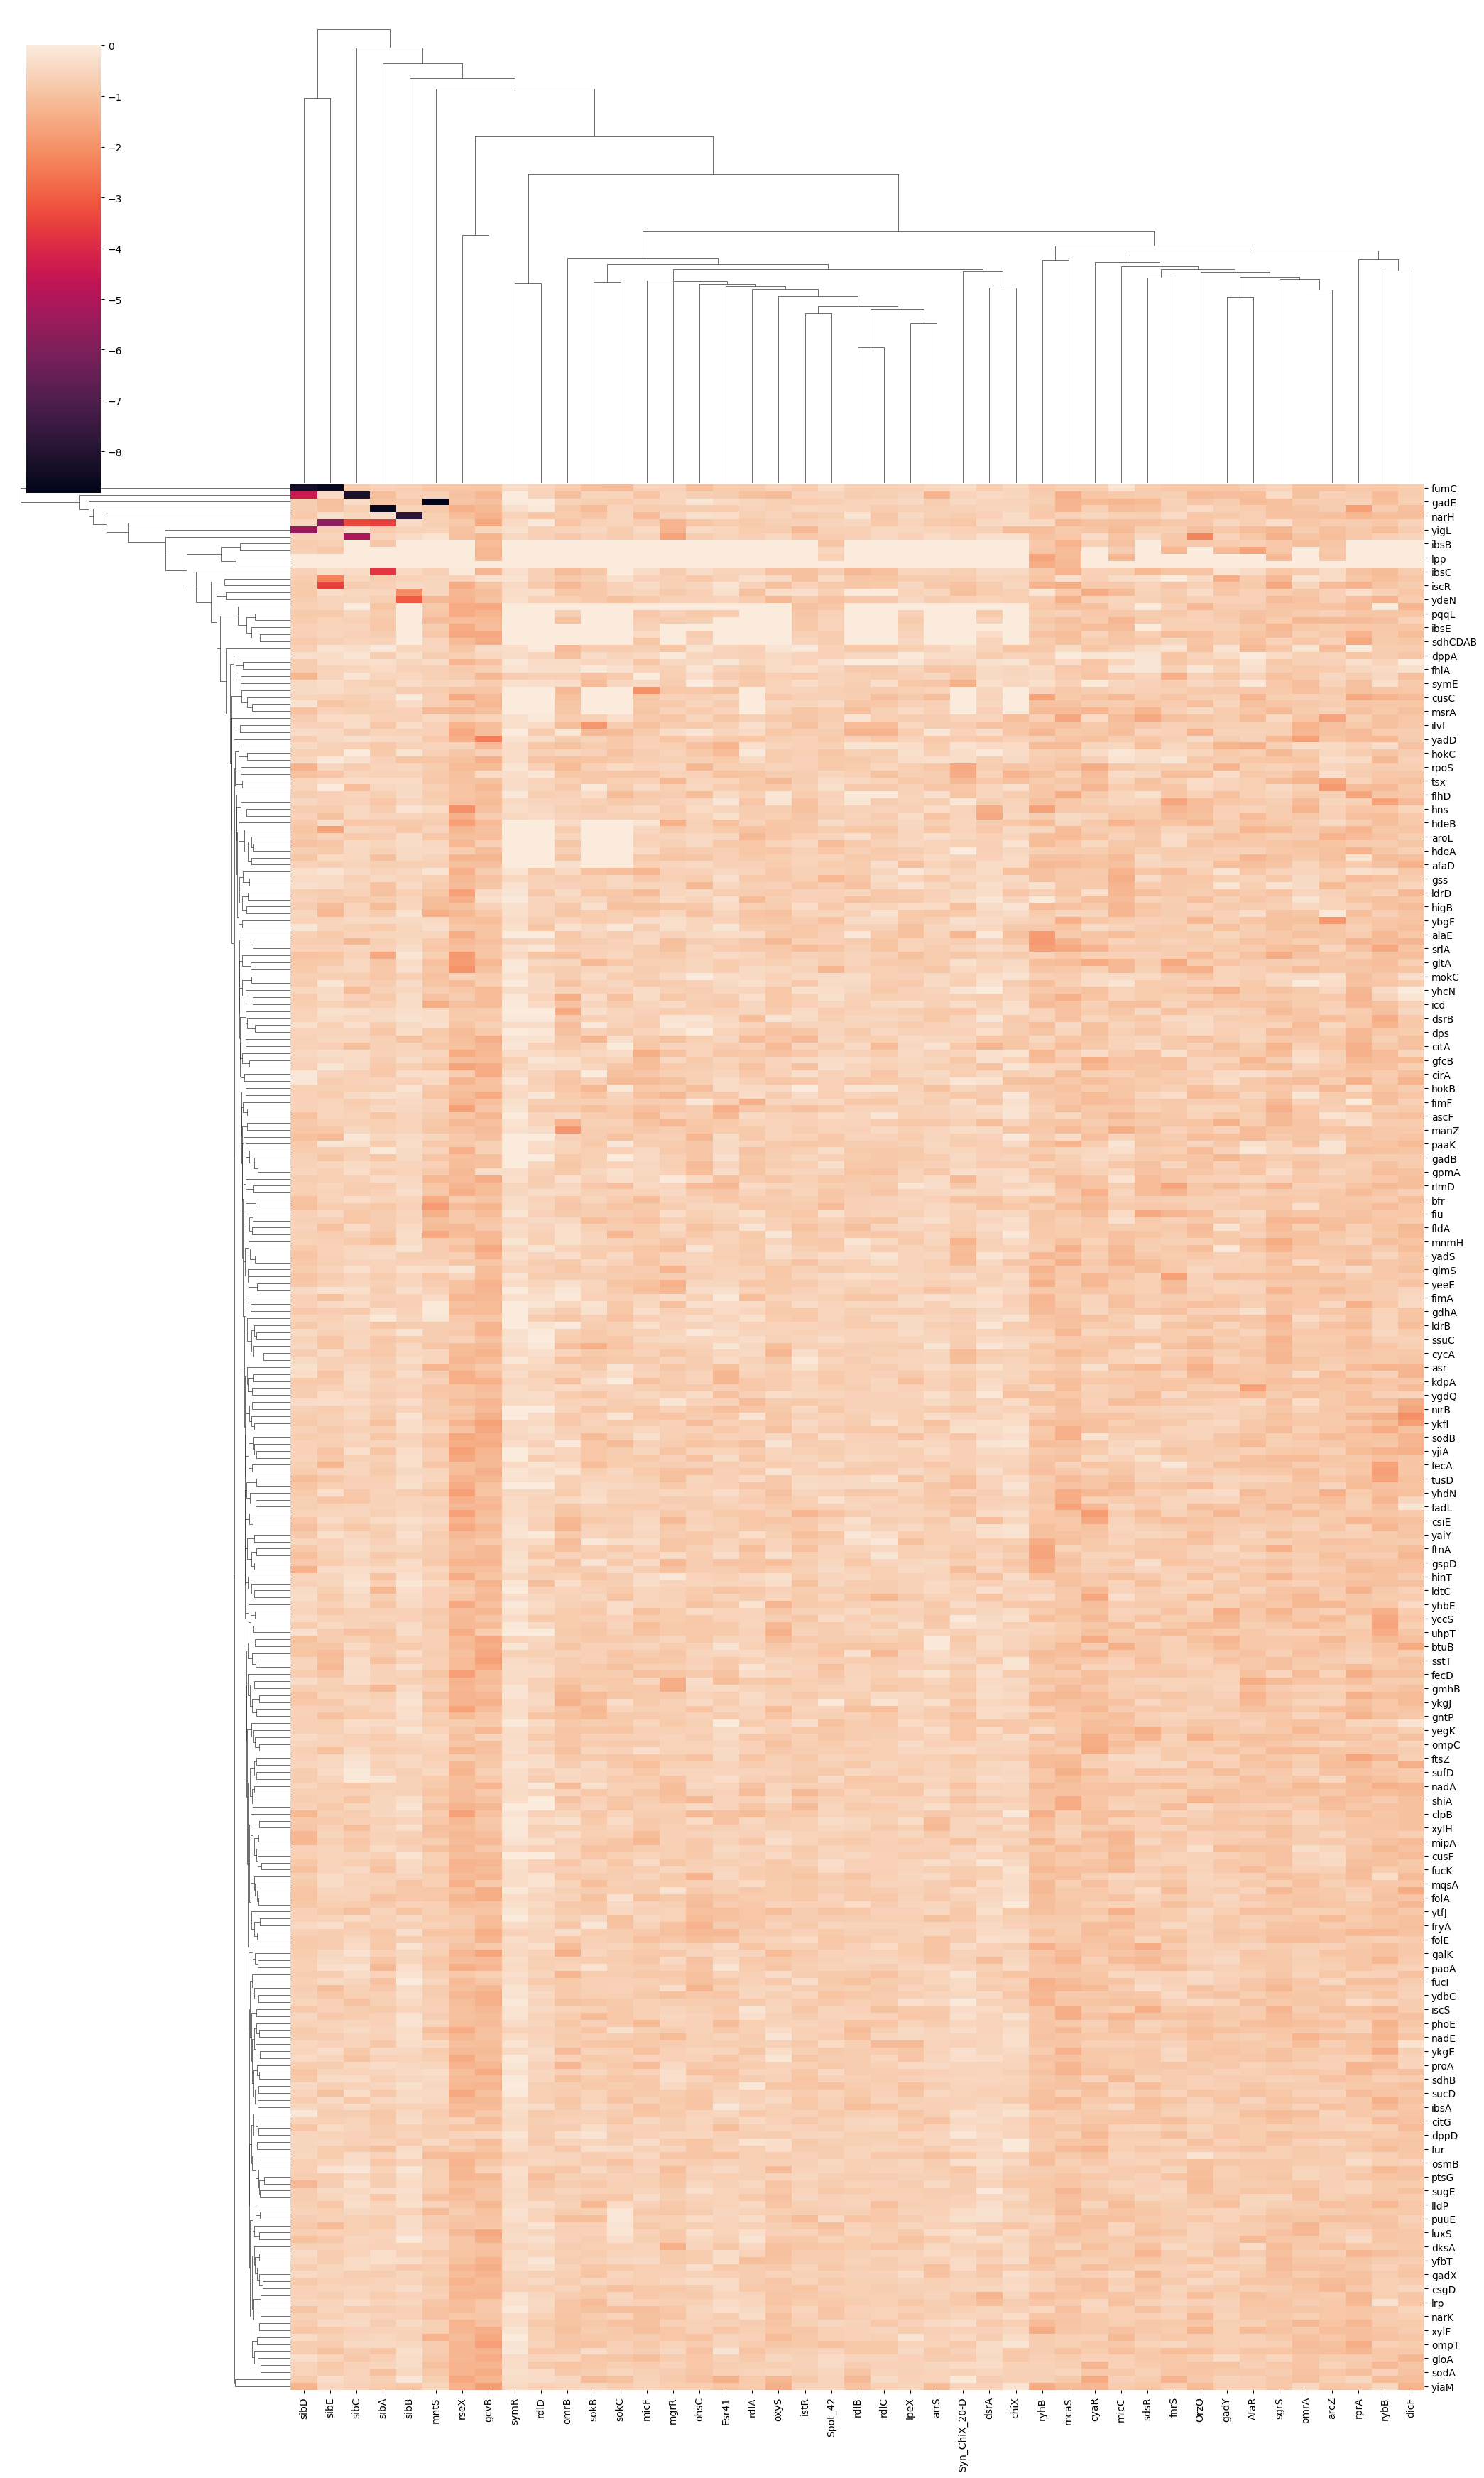

In [ ]:
fig = plt.figure(figsize=(24, 27))
sns.clustermap(energies_norm, figsize=(21, 35)) #, cmap= 'icefire') # Spectral, cubehelix, vlag
# plt.title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal)')

plt.savefig('data/figs/mRNA_official_energies_norm_cluster.jpg')


### Energy norm heatmap

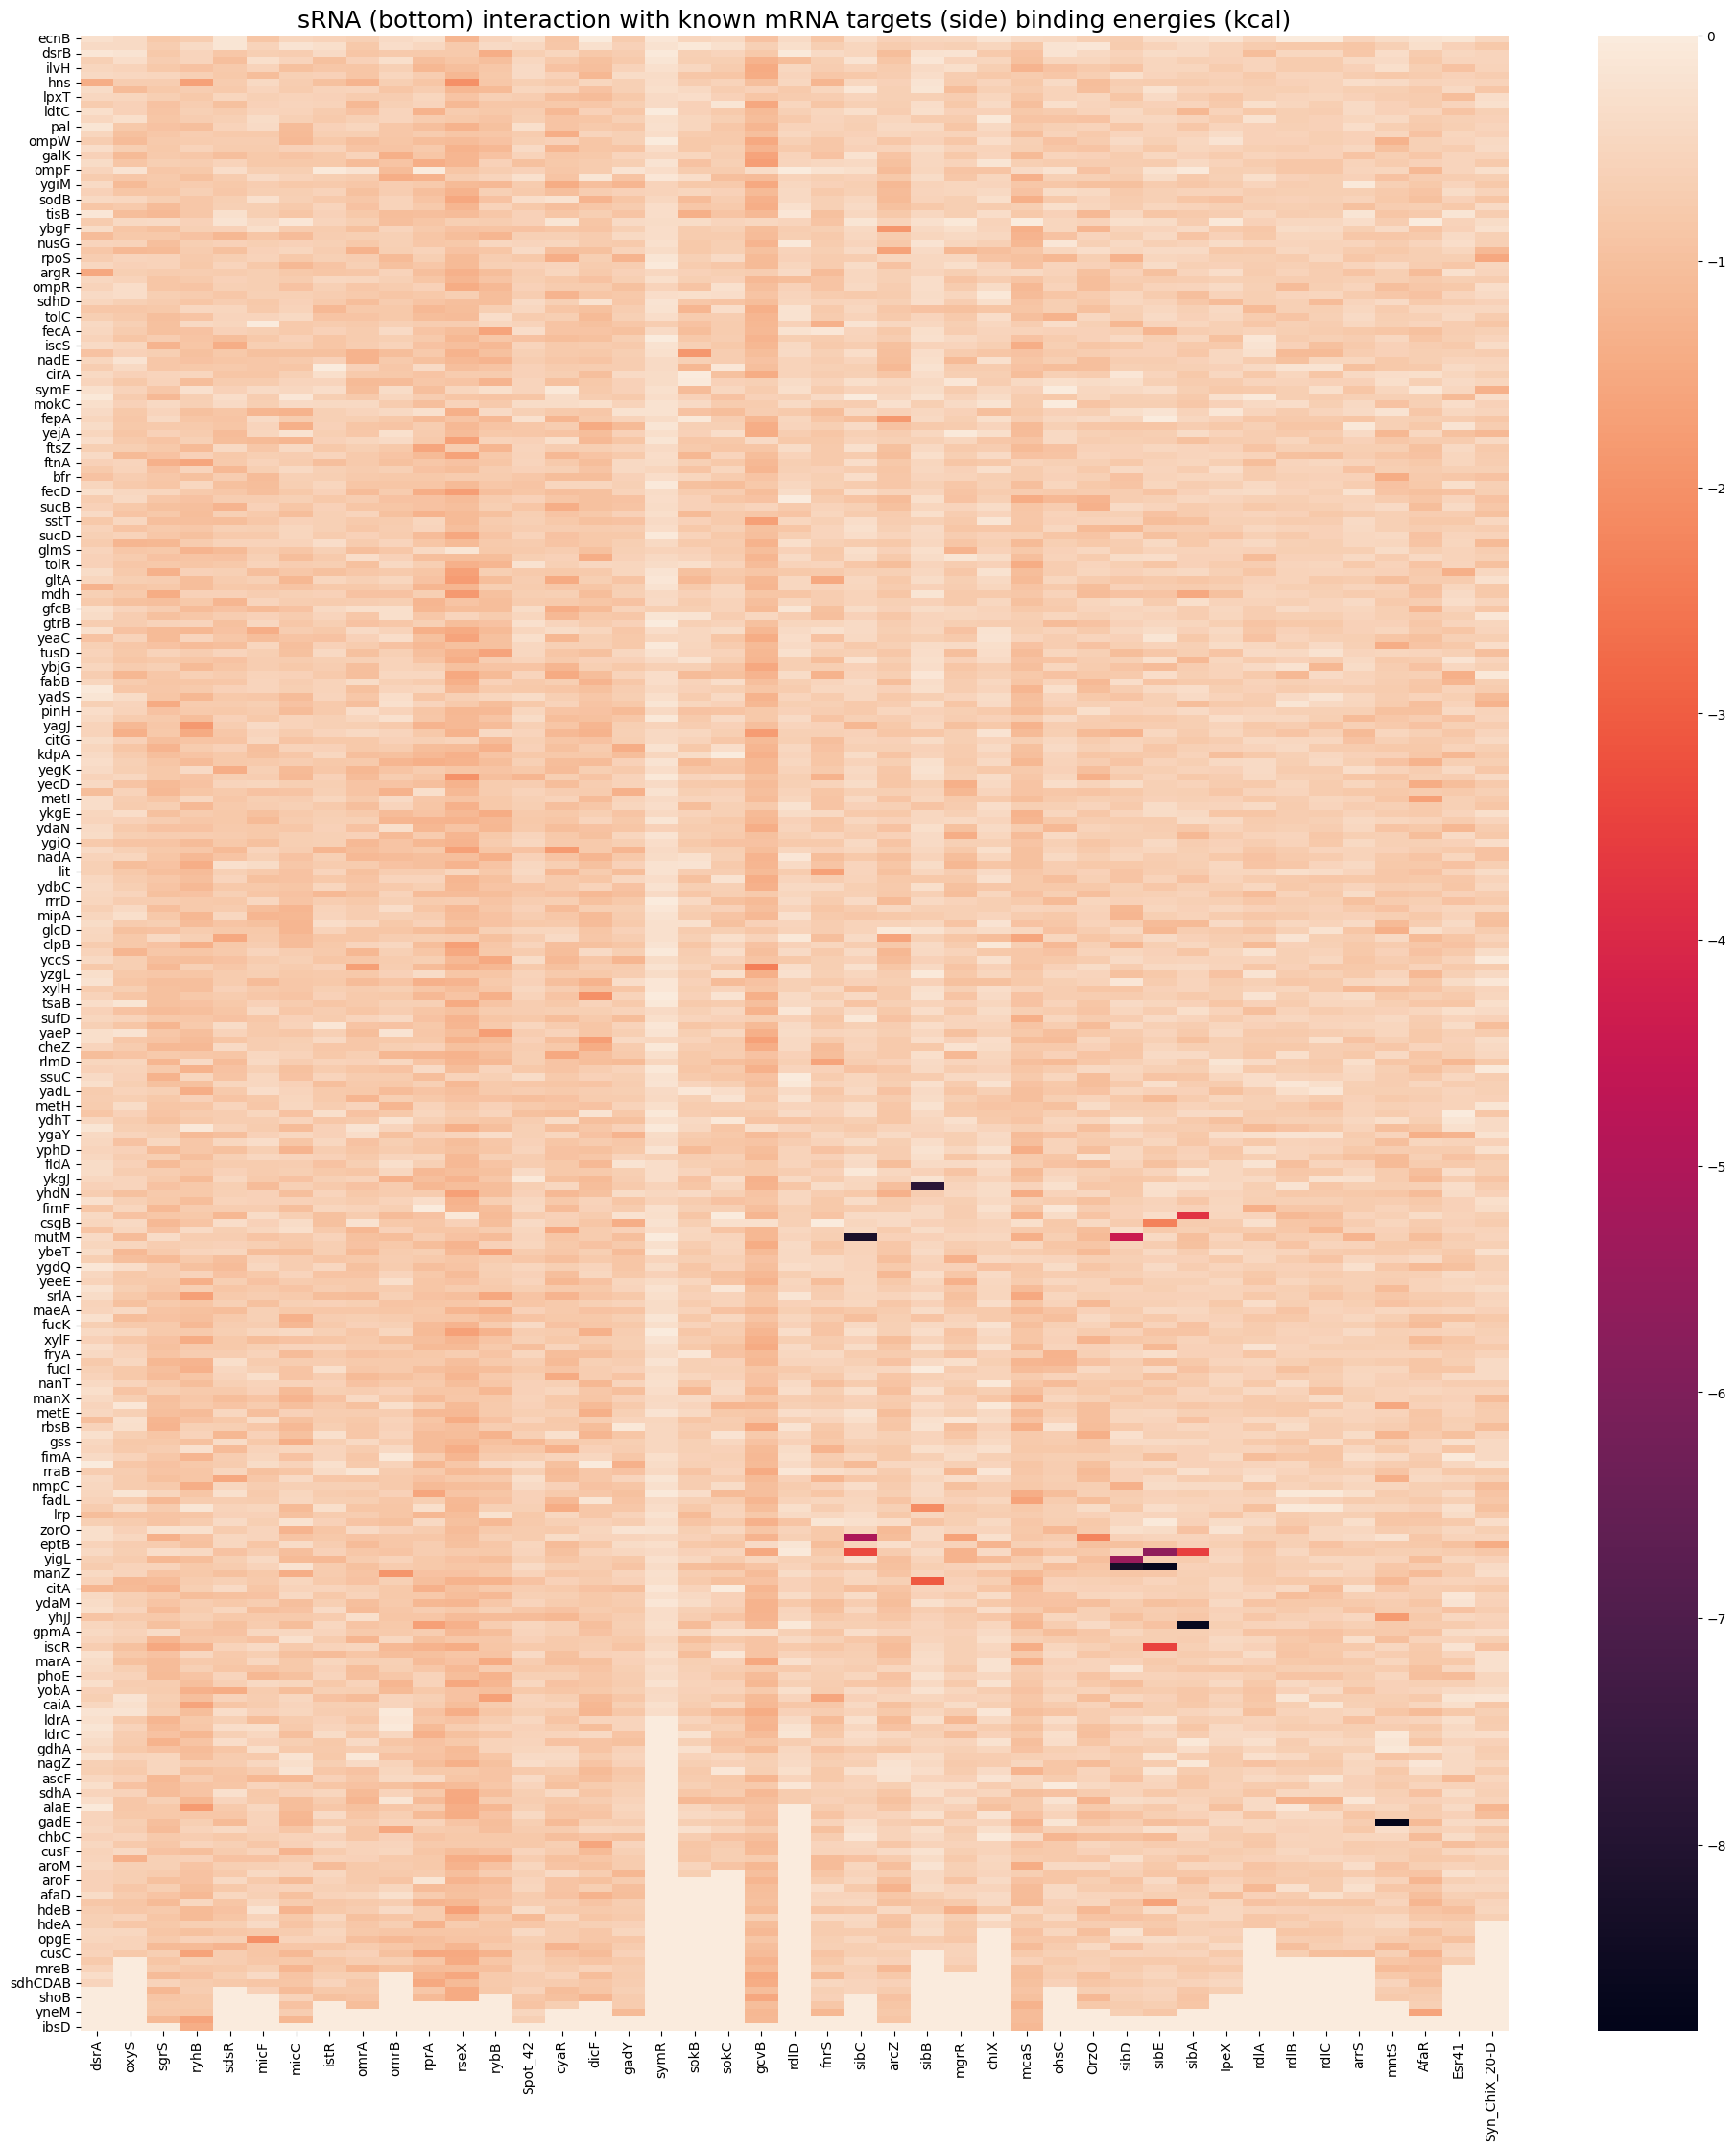

In [ ]:
fig = plt.figure(figsize=(24, 27))
sns.heatmap(energies_norm) #, cmap= 'icefire') # Spectral, cubehelix, vlag
plt.title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal)', fontsize=18)

plt.savefig('data/figs/mRNA_official_energies_norm.jpg')


## Assess specificity

In [68]:
specificity = pd.DataFrame(data=np.zeros_like(np.array([[float(vv['E']) for vv in v.values()] for v in sim_data_l.values()]).T),
                           columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))

# for s in data[data['Category 1'] != 'mRNA']['Interactor 1'].unique():
#     specificity.loc[list(data[(data['Interactor 1'] == s) & (data['Category 2'] == 'mRNA') & (
#         ~data['Sequence 2'].isna())]['Interactor 2'].unique()), s] = 1
    
# for s in data[data['Category 2'] != 'mRNA']['Interactor 2'].unique():
#     specificity.loc[list(data[(data['Interactor 2'] == s) & (data['Category 1'] == 'mRNA') & (
#         ~data['Sequence 1'].isna())]['Interactor 1'].unique()), s] = 1
    
for s in srnas:
    specificity.loc[list(data[(data['Interactor 1'] == s) & (data['Category 2'] == 'mRNA') & (
        ~data['Sequence 2'].isna())]['Interactor 2'].unique()), s] = 1
    specificity.loc[list(data[(data['Interactor 2'] == s) & (data['Category 1'] == 'mRNA') & (
        ~data['Sequence 1'].isna())]['Interactor 1'].unique()), s] = 1

In [ ]:
len(specificity.columns)

43

/tmp/ipykernel_1612861/3544752986.py:2: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.5)


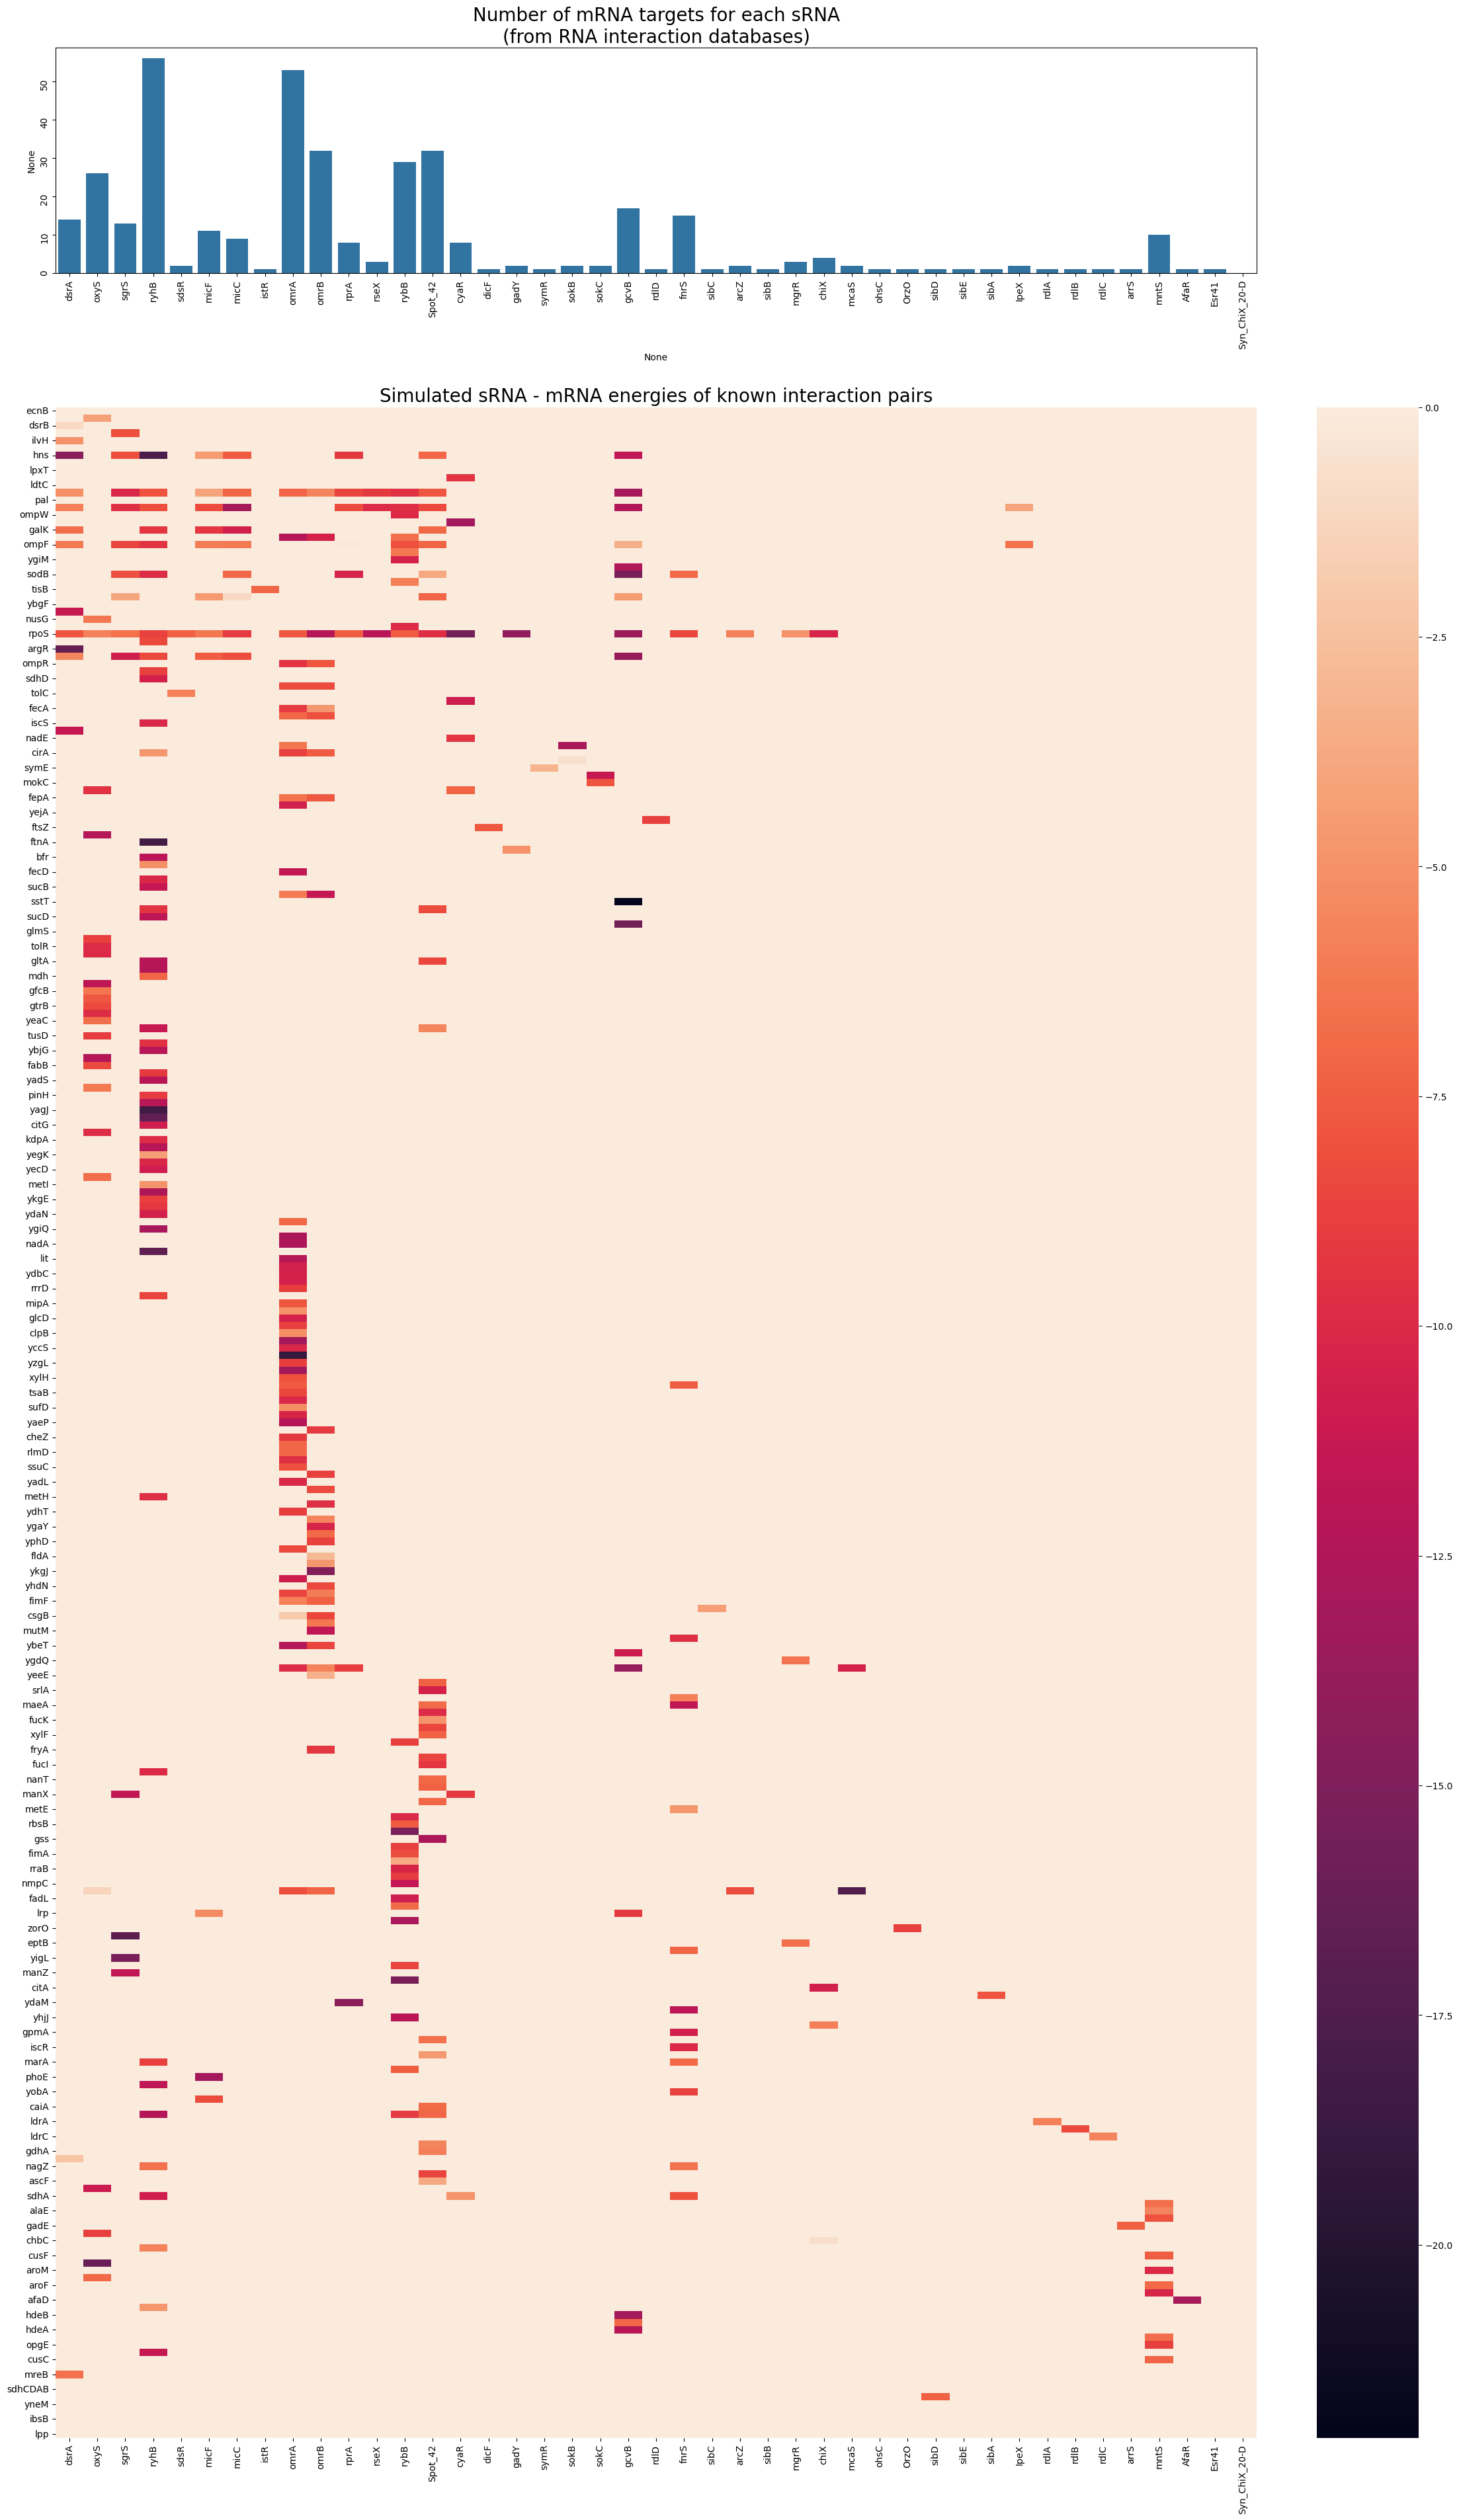

In [ ]:
fig, axs = plt.subplots(2,1,figsize=(22, 38), gridspec_kw={'height_ratios': [1, 9]}, constrained_layout=True)
fig.subplots_adjust(hspace=0.5)

sns.barplot(x=specificity.columns, y=specificity.sum(axis=0), ax=axs[0]) #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
# sns.barplot(specificity.sum(axis=0), ax=axs[0]) #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
axs[0].tick_params(rotation=90) #, labelsize=7)
axs[0].set_title('Number of mRNA targets for each sRNA\n(from RNA interaction databases)', fontsize=20)


sns.heatmap(specificity * energies, ax=axs[1])
axs[1].set_title('Simulated sRNA - mRNA energies of known interaction pairs', fontsize=20)

plt.savefig('data/figs/mRNA_official_energies_known_pairs.jpg')


/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.10/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


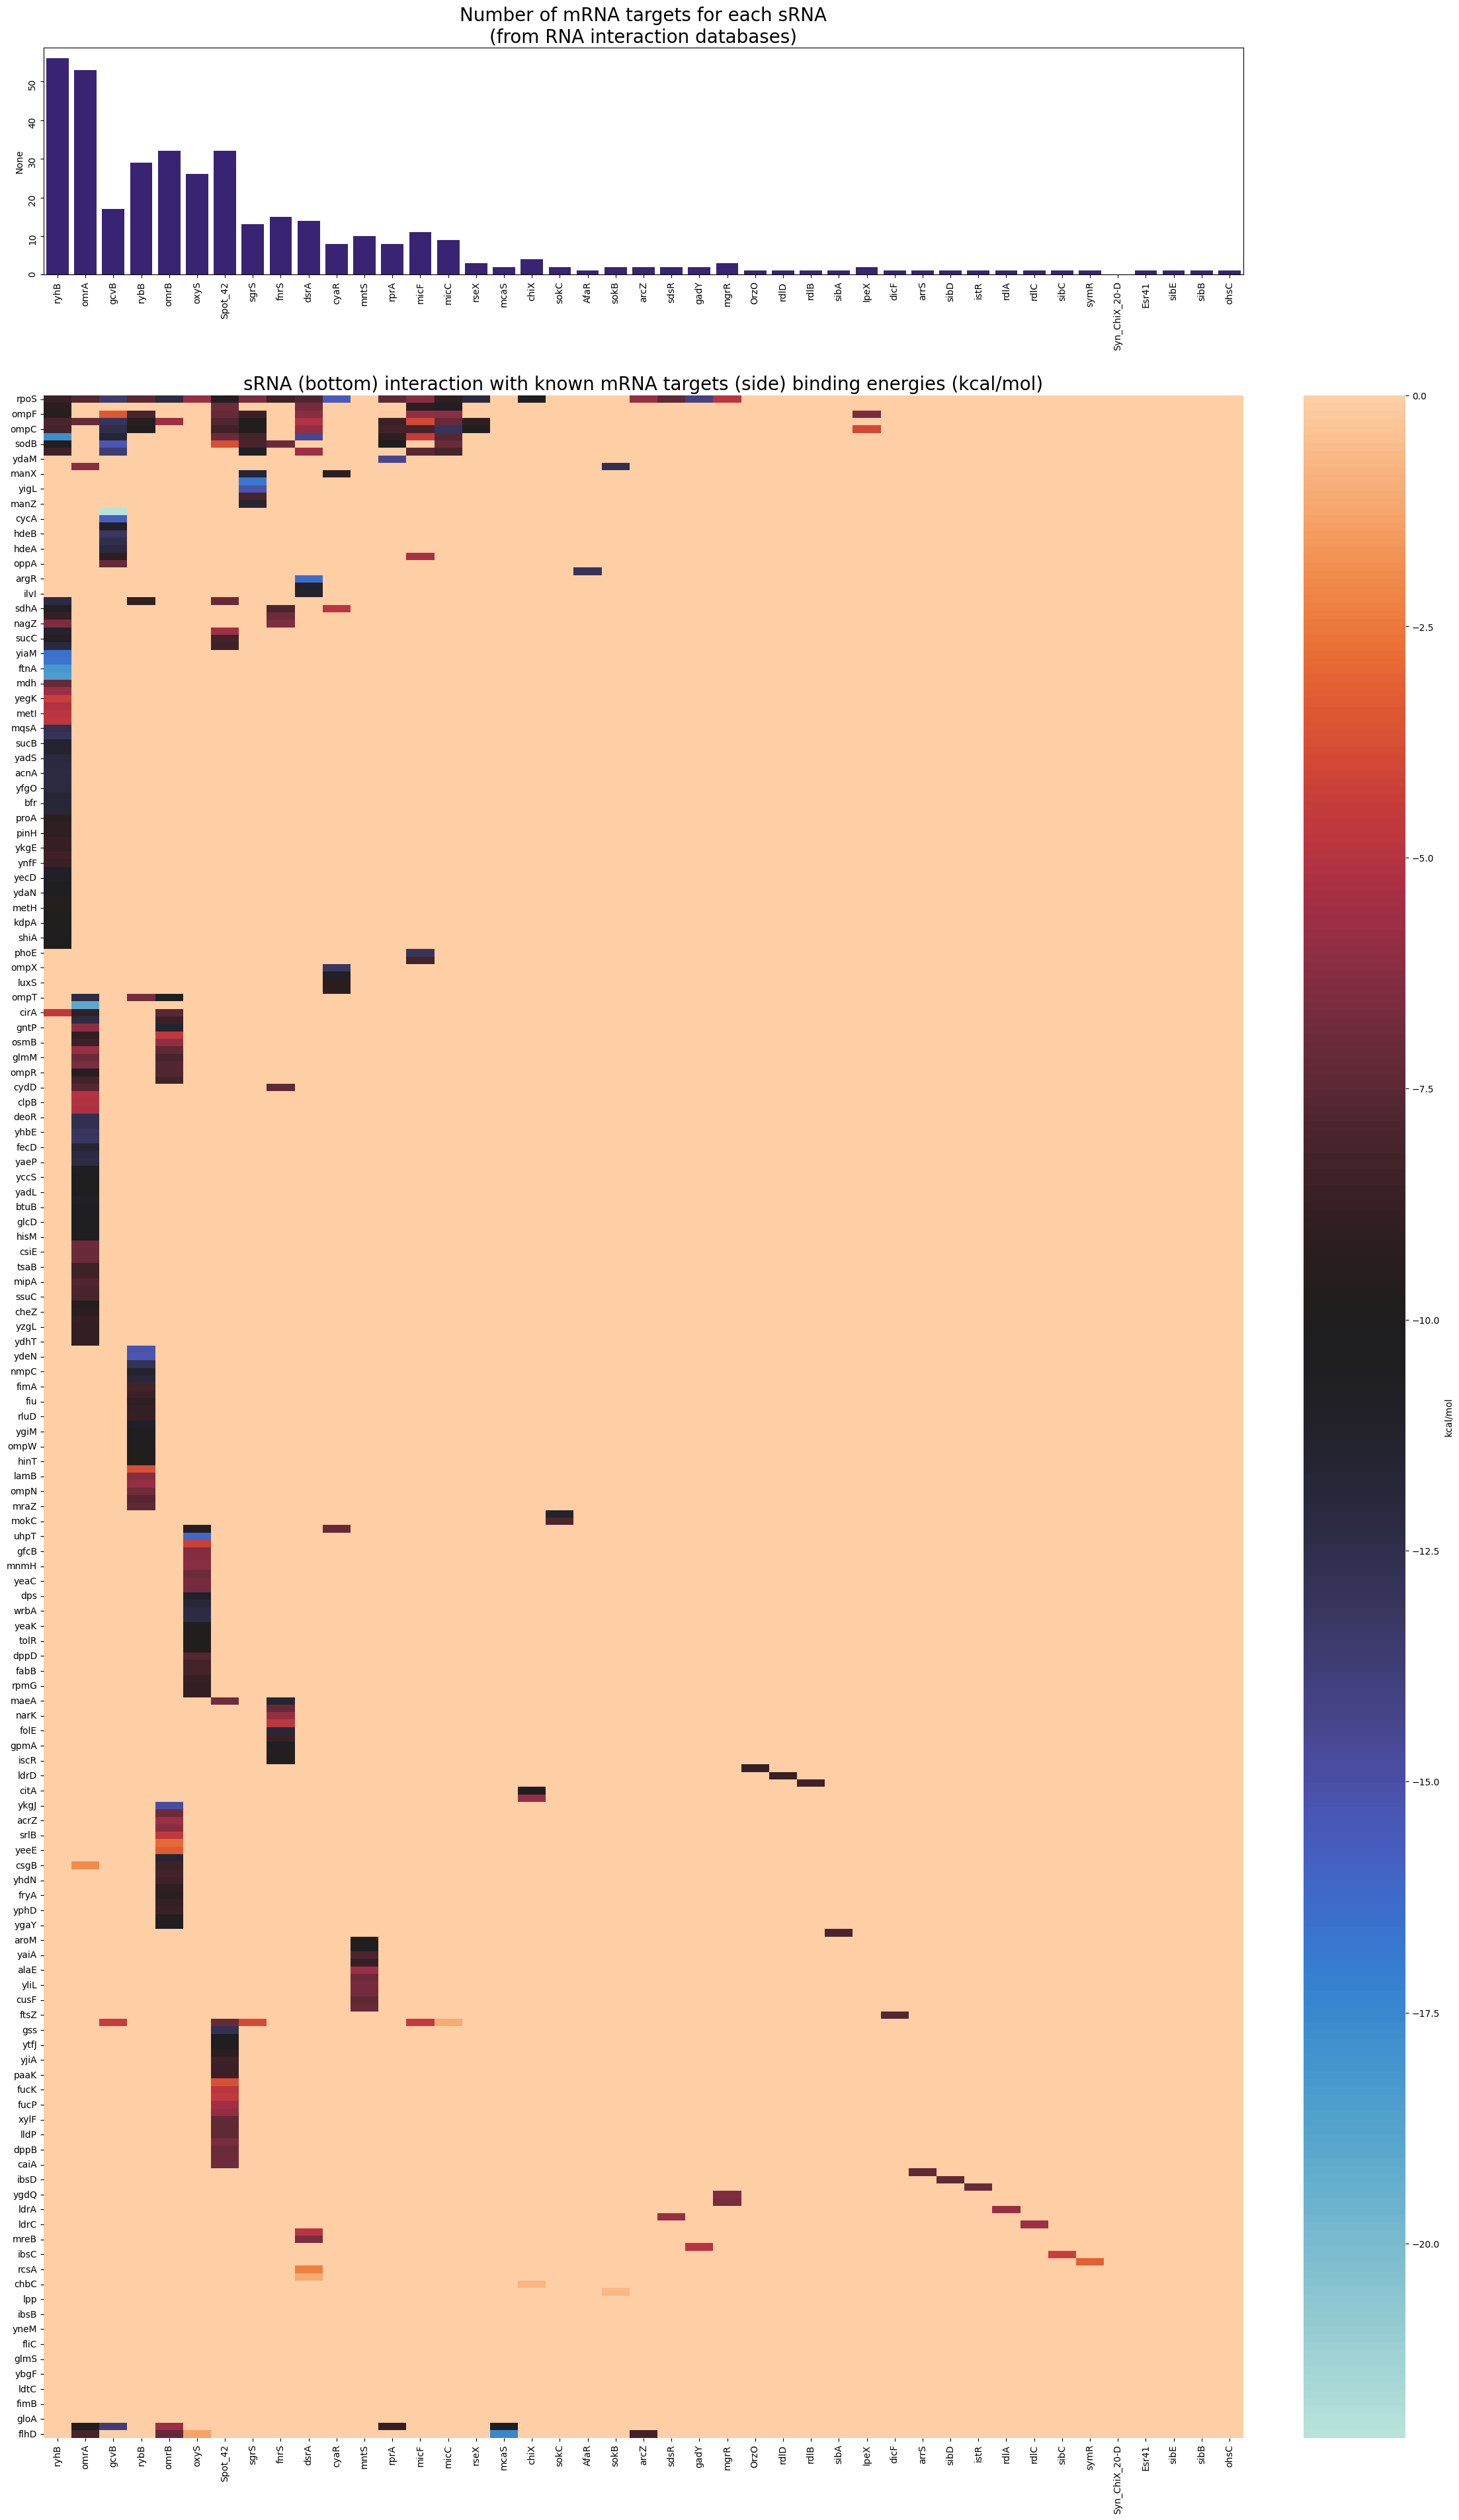

In [102]:
g_clust_spec = sns.clustermap(specificity * energies)
plt.close()

fig, axs = plt.subplots(2,1,figsize=(22, 38), gridspec_kw={'height_ratios': [1, 9]}, constrained_layout=True)

center = -10
emin = (energies * specificity).min().min()
emax = (energies * specificity).max().max()
total_colors = 100
n_colors_low = int(total_colors * (np.abs(emin - center) / (emax - emin)))
n_colors_high = int(total_colors * (np.abs(emax - center) / (emax - emin)))
custom_palette_clust = sns.blend_palette(
    sns.color_palette('icefire', n_colors=n_colors_low*2).as_hex()[:n_colors_low]
    + sns.color_palette('icefire', n_colors=n_colors_high*2).as_hex()[n_colors_high:],
    as_cmap=True)
sns.barplot(x=specificity.columns[g_clust_spec.dendrogram_col.reordered_ind], 
            y=specificity[specificity.columns[g_clust_spec.dendrogram_col.reordered_ind]].sum(axis=0), 
            ax=axs[0], color="#31177f") #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
axs[0].tick_params(rotation=90) #, labelsize=7)
axs[0].set_xlabel('')
axs[0].set_title('Number of mRNA targets for each sRNA\n(from RNA interaction databases)', fontsize=20)

sns.heatmap((energies * specificity).iloc[g_clust_spec.dendrogram_row.reordered_ind][energies.columns[g_clust_spec.dendrogram_col.reordered_ind]], 
            cmap=custom_palette_clust, ax=axs[1], cbar_kws={'label': 'kcal/mol'}) # Spectral, cubehelix, vlag
axs[1].set_title('sRNA (bottom) interaction with known mRNA targets (side) binding energies (kcal/mol)', fontsize=20)

# plt.tight_layout()
plt.savefig('data/figs/mRNA_official_energies_masked.jpg', dpi=300, bbox_inches='tight')

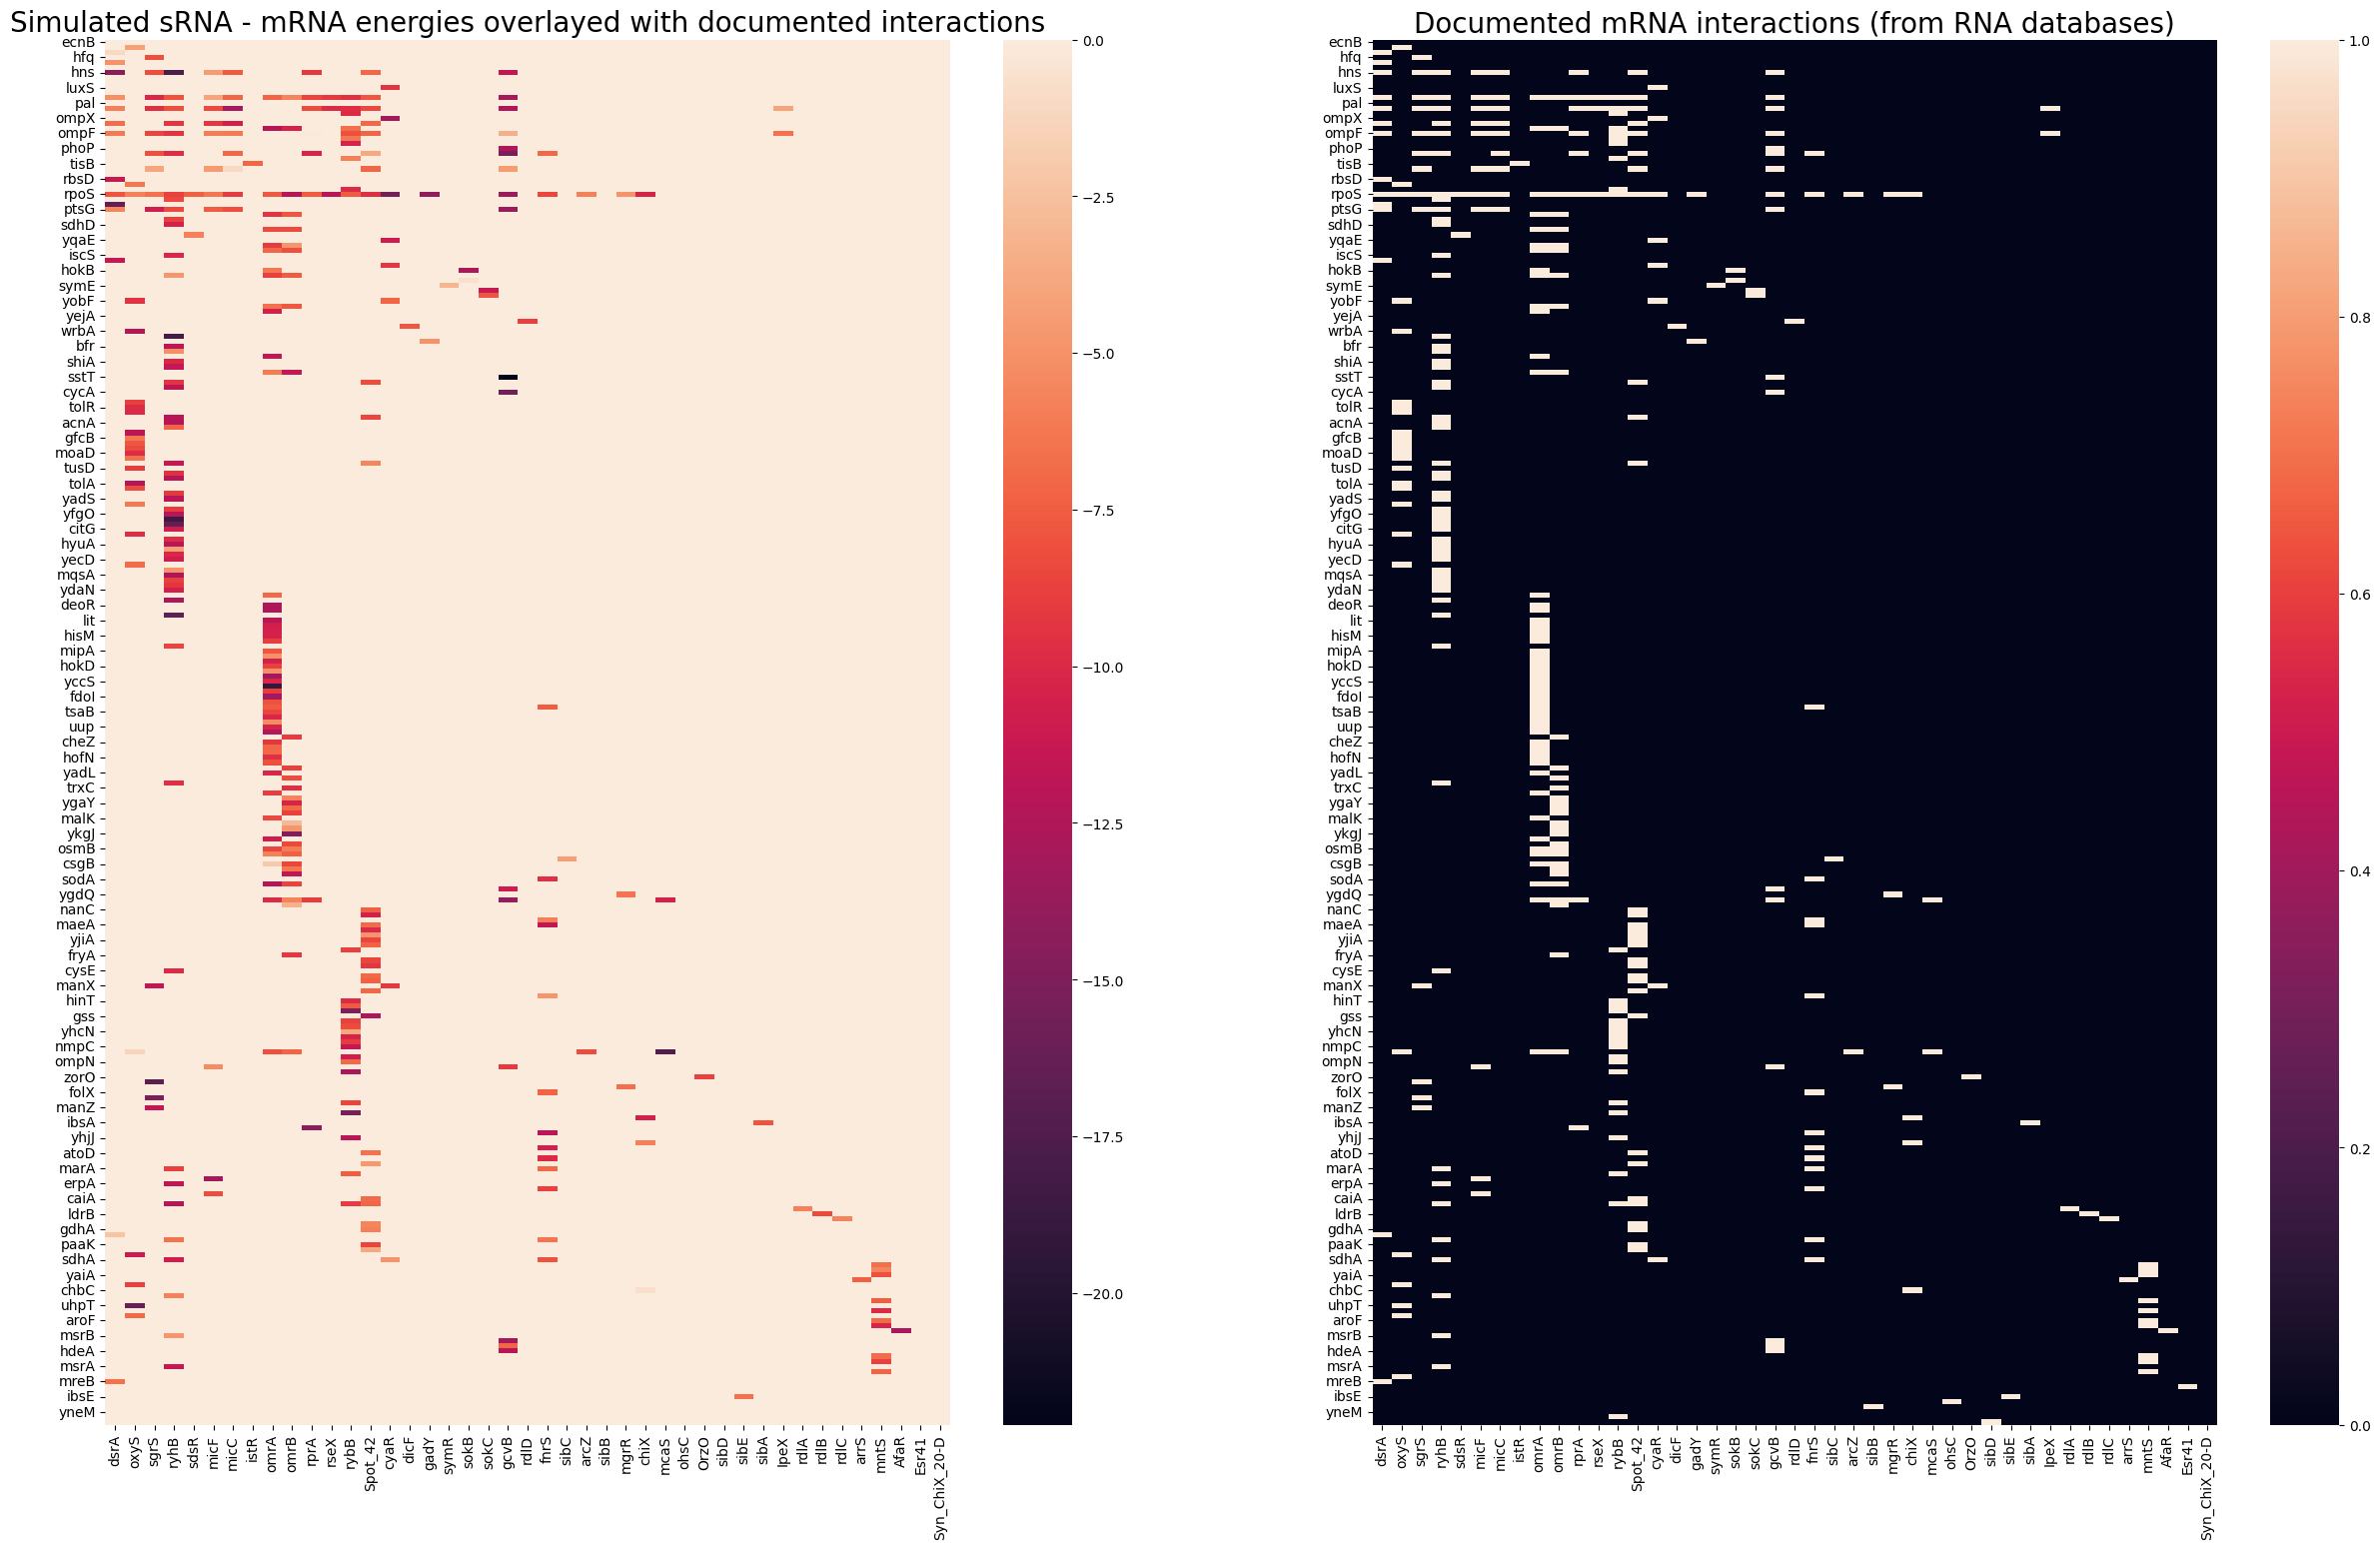

In [ ]:
# threshold_binding_E = (specificity * energies).min(axis=0)
threshold_binding_E = np.where(specificity.sum(axis=0) > 0, (specificity * energies).max(axis=0), 0)

plt.figure(figsize=(30, 18))
ax = plt.subplot(1, 2, 1)
mask = (np.ones_like(energies) * (specificity.sum(axis=0) > 0).to_numpy()[None, :])
sns.heatmap(specificity * energies)
plt.title('Simulated sRNA - mRNA energies overlayed with documented interactions', fontsize=20)

ax = plt.subplot(1, 2, 2)
sns.heatmap(specificity)
plt.title('Documented mRNA interactions (from RNA databases)', fontsize=20)

plt.savefig('data/figs/mRNA_official_comparison.jpg')


In [ ]:
# sns.scatterplot(x=(specificity * energies).sum(axis=0) / (np.where(specificity.sum(axis=0) == 0, 1, specificity.sum(axis=0))),
#                 y=energies.sum(axis=0) / (energies < 0).sum(axis=0))

# plt.xlabel('Average binding energy of documented interactions per sRNA')
# plt.ylabel('Average binding energy for all mRNAs per sRNA')
# plt.title('')

In [ ]:
specificity_missing_cols = [c for c in specificity.columns if c not in energies.columns]
print('Not including the following documented interaction targets likely due to missing sequence:',
      specificity_missing_cols)
specificity = specificity.drop(columns=specificity_missing_cols)

Not including the following documented interaction targets likely due to missing sequence: []


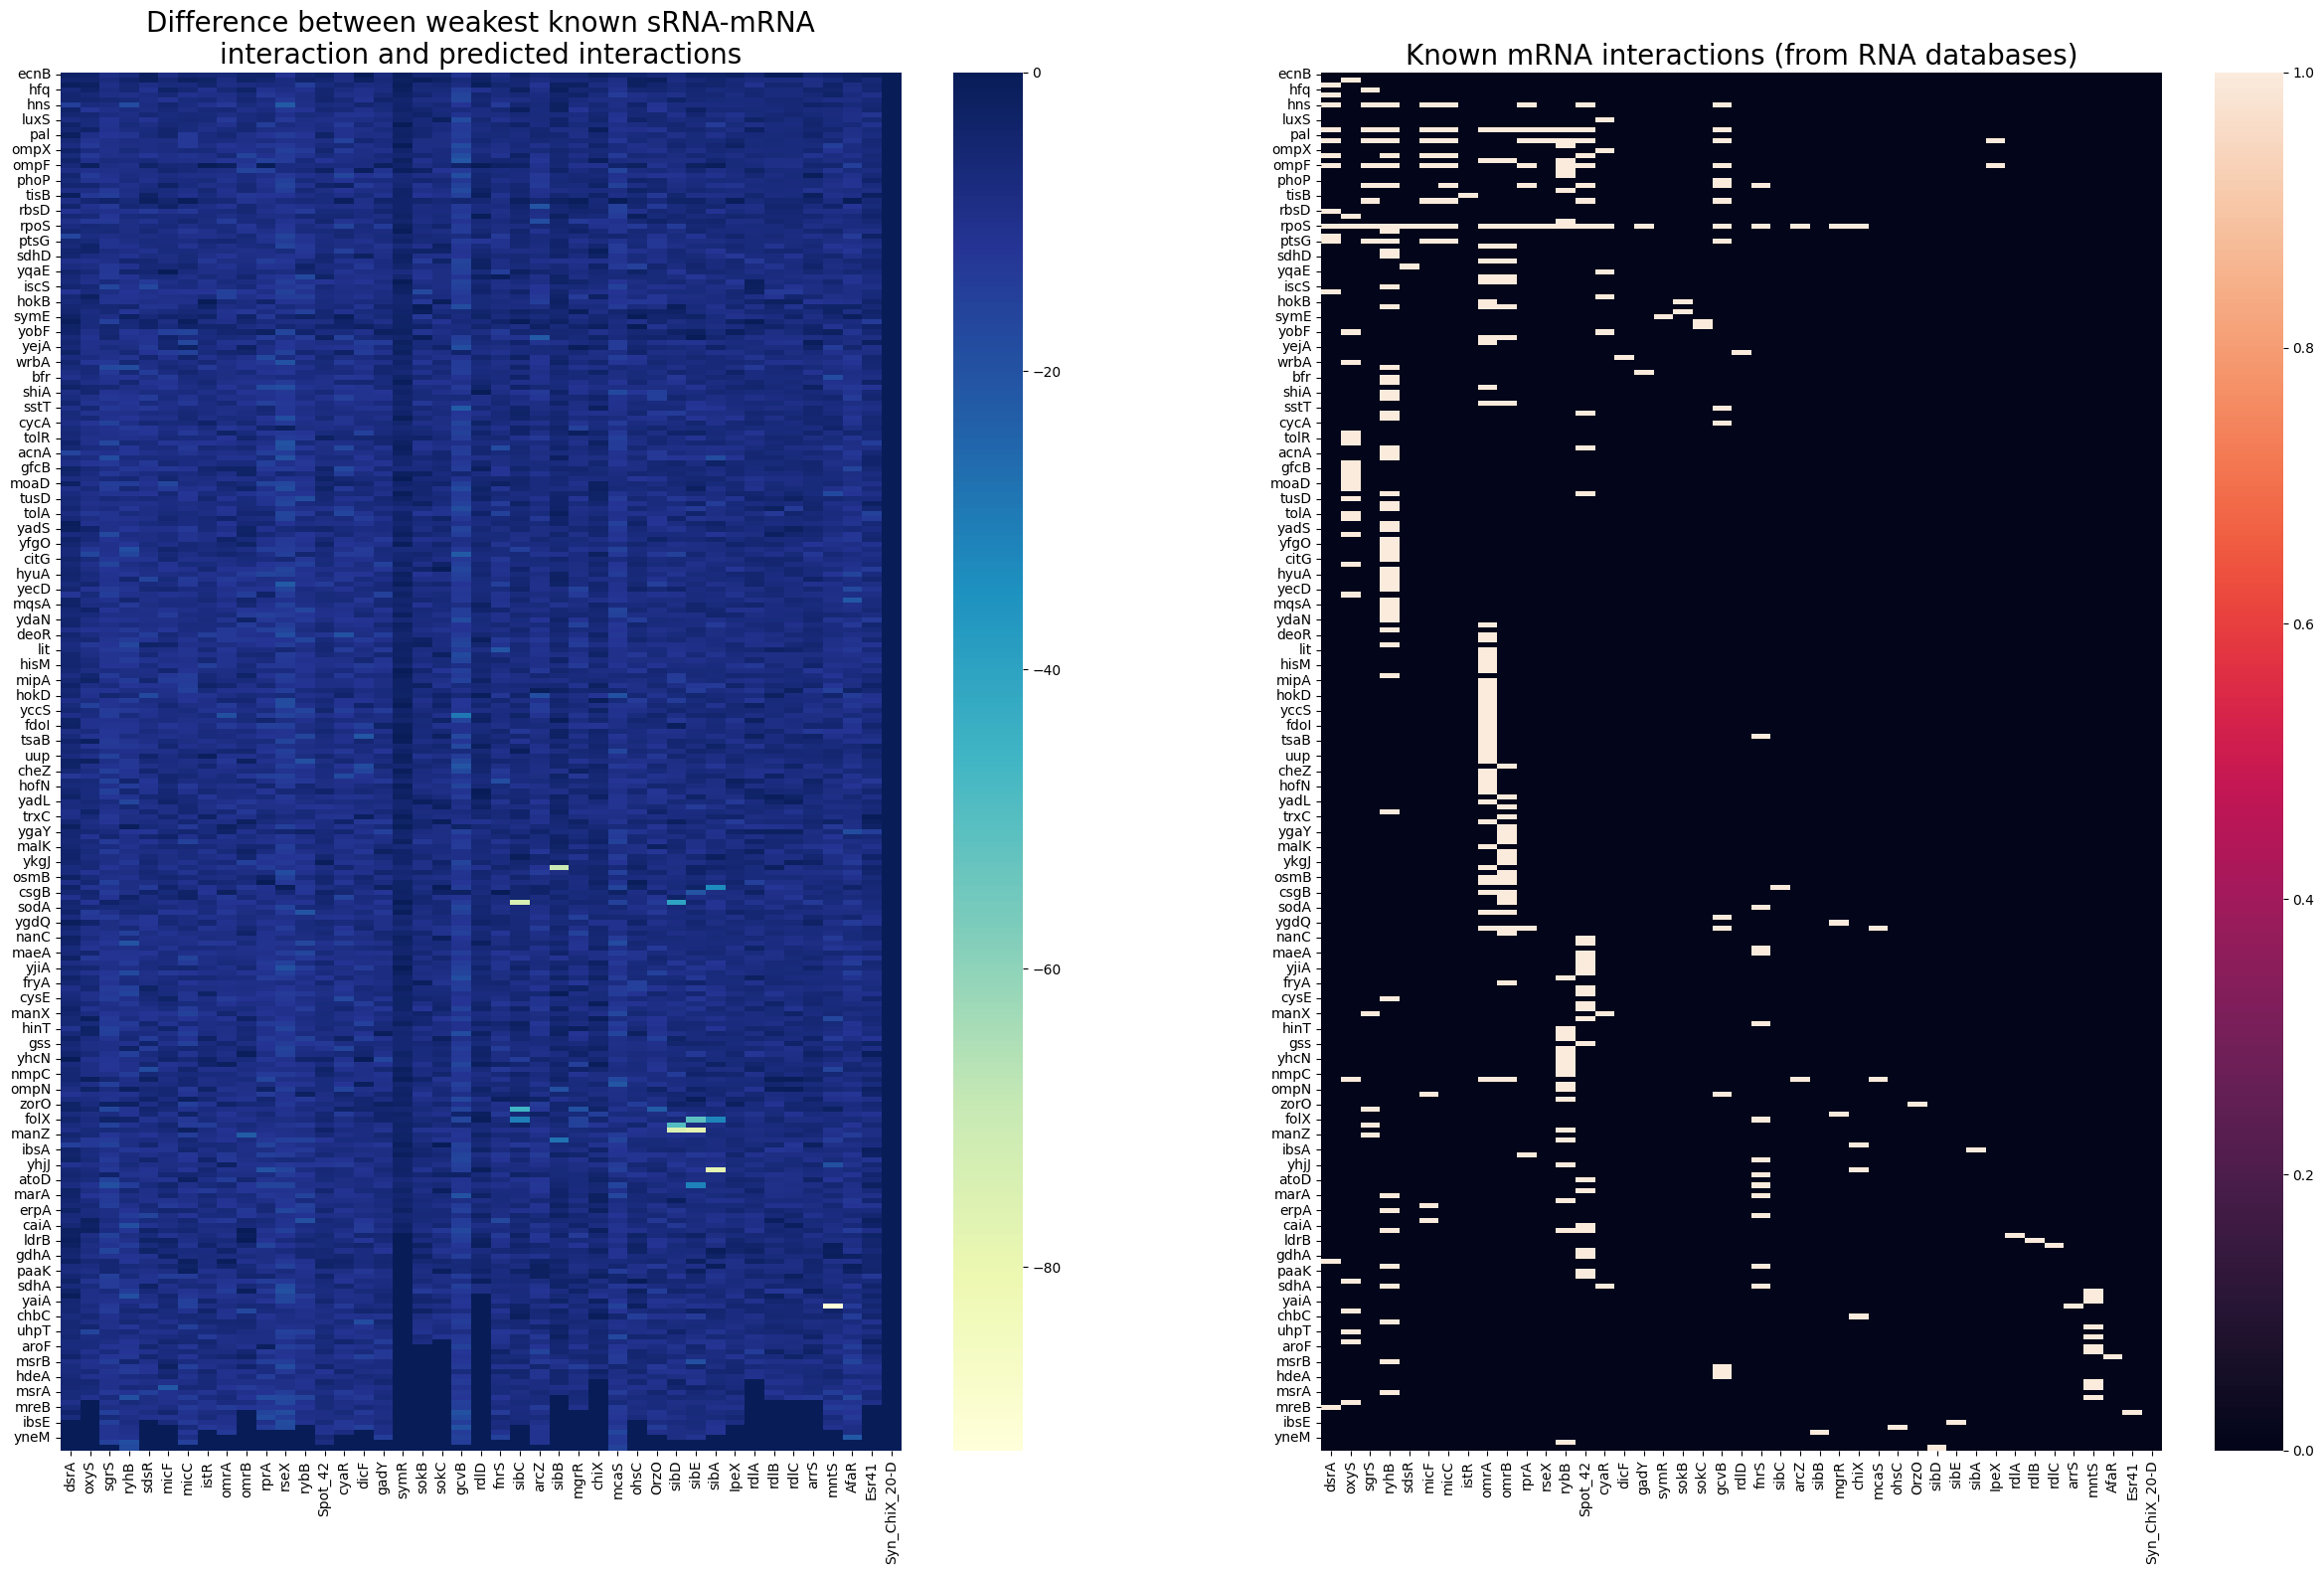

In [ ]:
# threshold_binding_E = (specificity * energies).min(axis=0)
threshold_binding_E = np.where(specificity.sum(axis=0) > 0, (specificity * energies).max(axis=0), 0)

plt.figure(figsize=(30, 18))
ax = plt.subplot(1, 2, 1)
mask = (np.ones_like(energies) * (specificity.sum(axis=0) > 0).to_numpy()[None, :])
sns.heatmap(energies * mask - (
    np.ones_like(energies) * threshold_binding_E[None, :]), cmap='YlGnBu')
plt.title('Difference between weakest known sRNA-mRNA\ninteraction and predicted interactions', fontsize=20)

ax = plt.subplot(1, 2, 2)
sns.heatmap(specificity)
plt.title('Known mRNA interactions (from RNA databases)', fontsize=20)

plt.savefig('data/figs/mRNA_official_energies_known_pairs_weakestE.jpg')


## Look at binding probability

In [ ]:
pus1 = pd.DataFrame(data=np.array([[float(vv['Pu1']) for vv in v.values()] for v in sim_data_l.values()]).T,
                    columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))
pus2 = pd.DataFrame(data=np.array([[float(vv['Pu2']) for vv in v.values()] for v in sim_data_l.values()]).T,
                    columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))
subseq = pd.DataFrame(data=np.array([[len(vv['subseqDB'].split('&')[0]) - 1 if len(vv['subseqDB'].split('&')[0]) > 0 else 0 for vv in v.values()] for v in sim_data_l.values()]).T,
                      columns=list(sim_data_l.keys()), index=list(list(sim_data_l.values())[0].keys()))

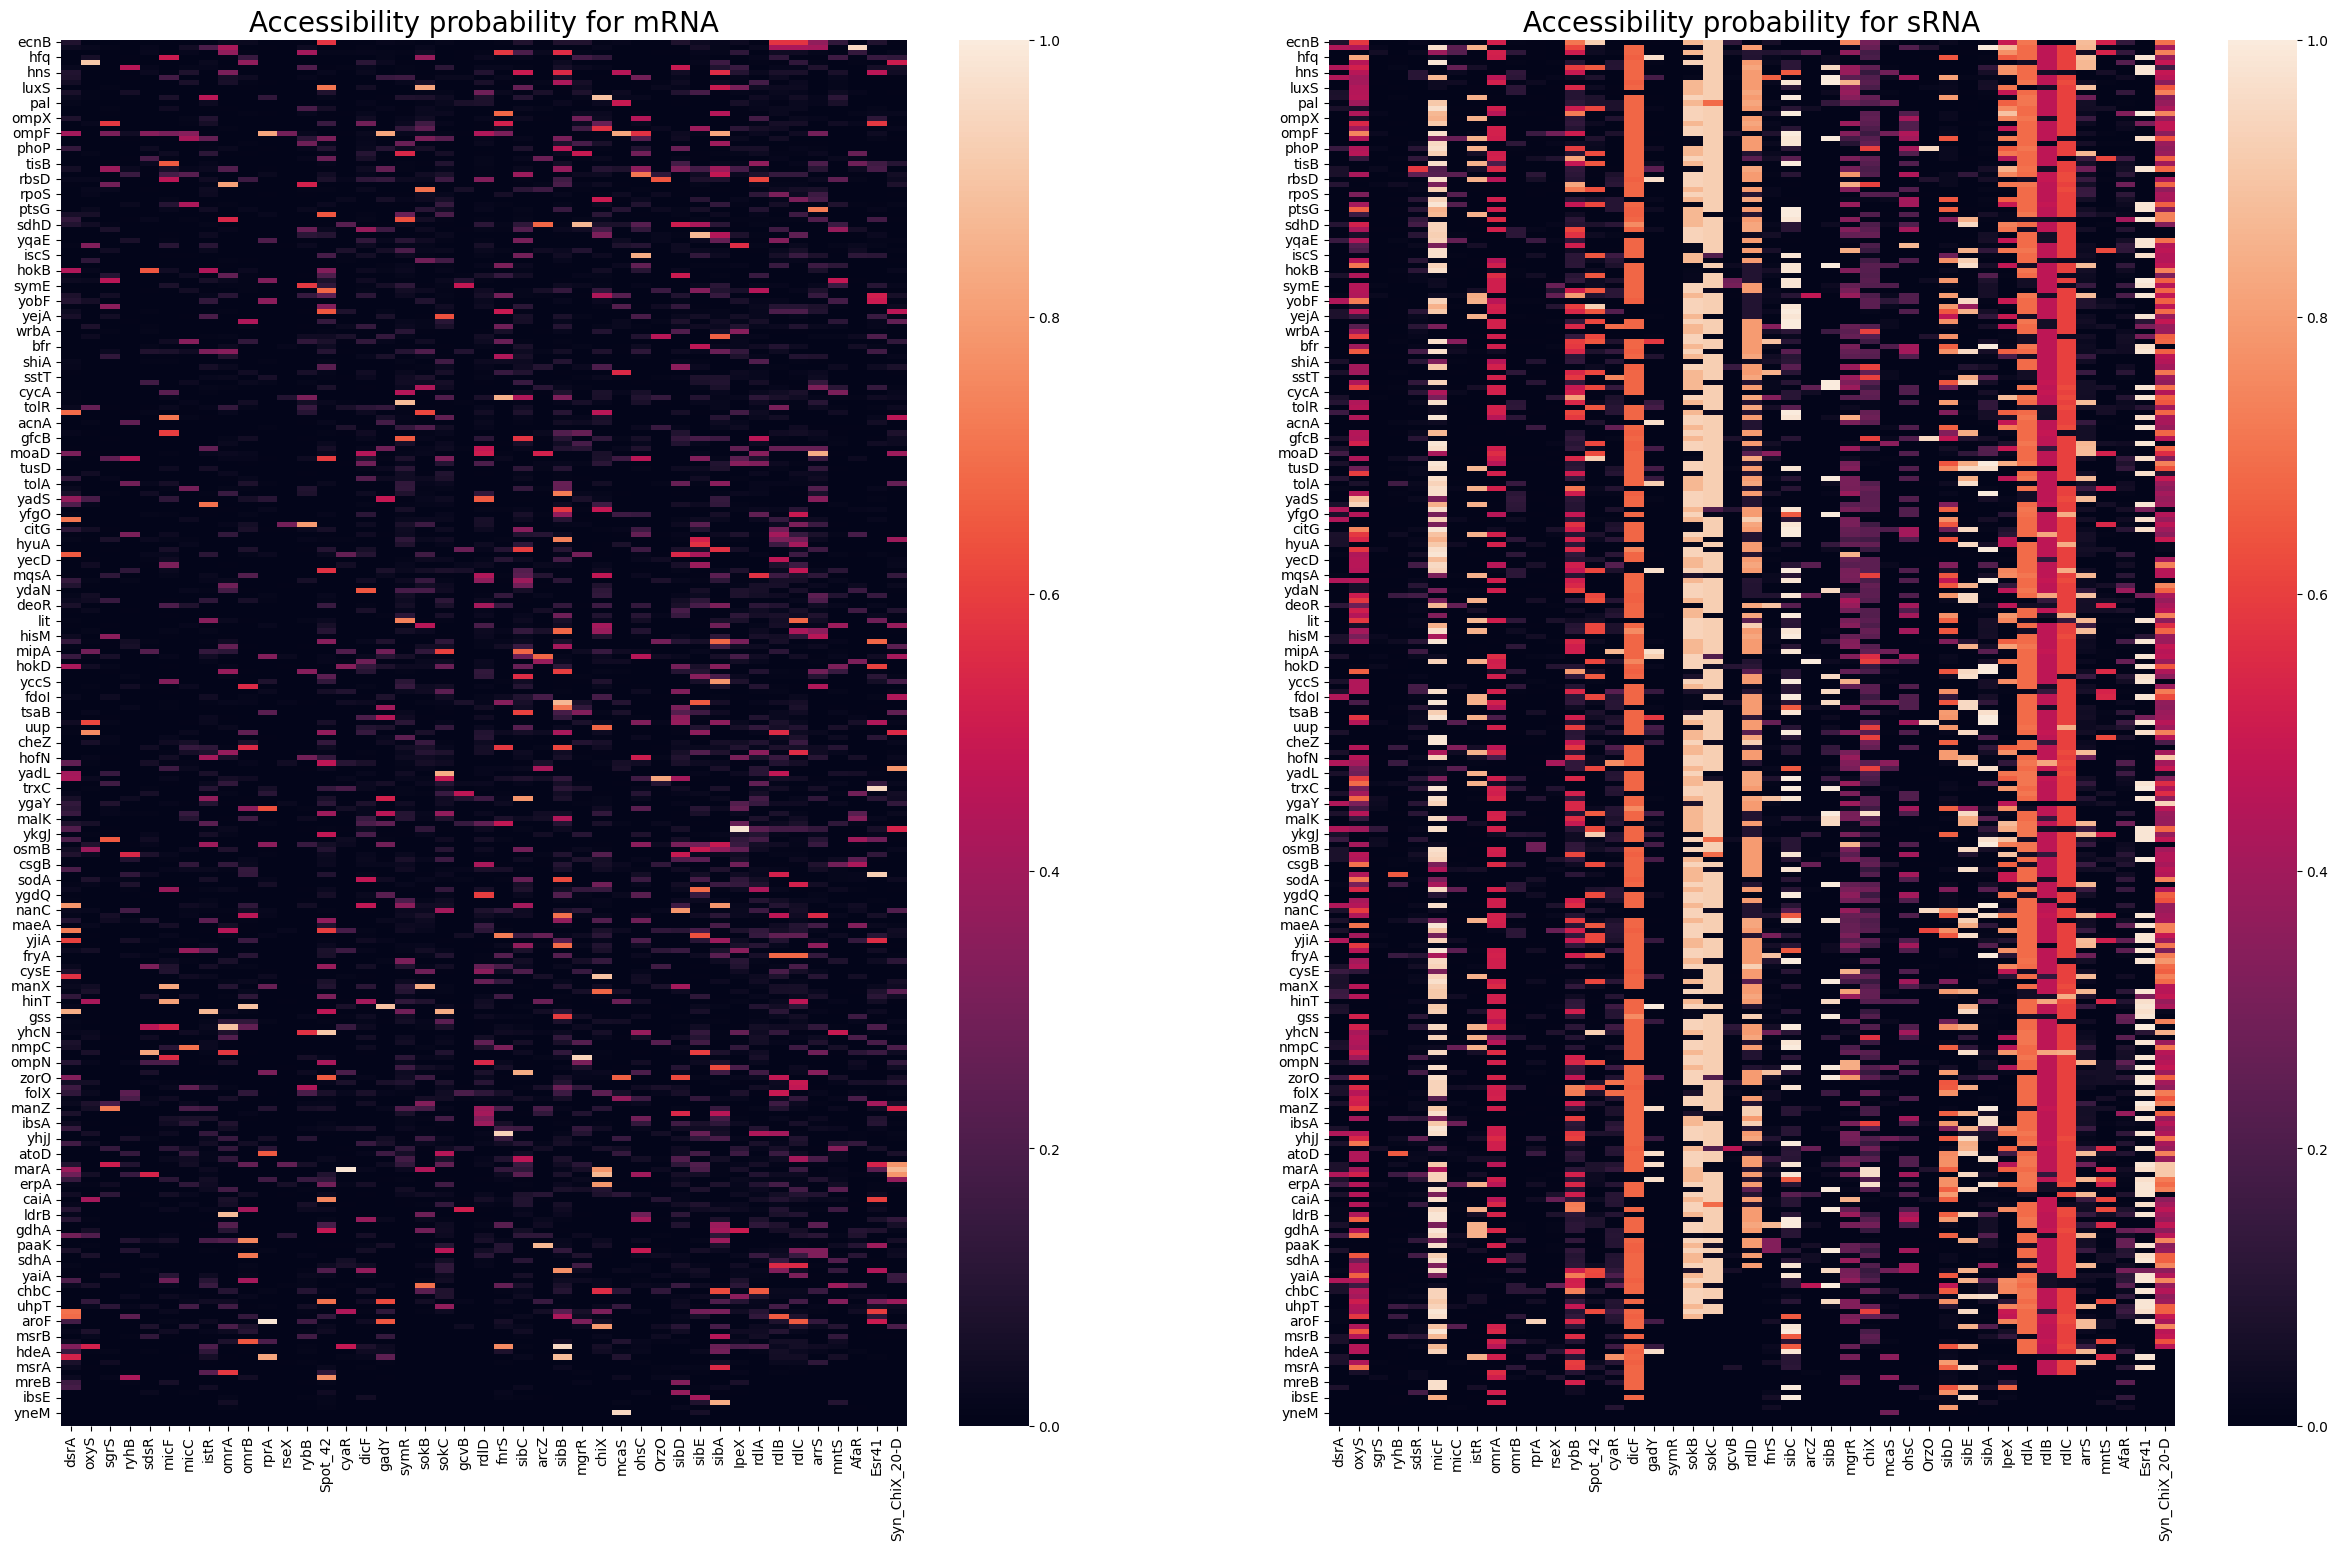

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(30, 18))

# ax = plt.subplot(1,2,1)
sns.heatmap(pus1, ax=axs[0], vmin=np.min([pus1.min(), pus2.min()]), vmax=np.max([pus1.max(), pus2.max()])) #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
# axs[0].tick_params(rotation=90) #, labelsize=7)
axs[0].set_title('Accessibility probability for mRNA', fontsize=20)

ax = plt.subplot(1,2,2)
sns.heatmap(pus2, ax=axs[1], vmin=np.min([pus1.min(), pus2.min()]), vmax=np.max([pus1.max(), pus2.max()]))
axs[1].set_title('Accessibility probability for sRNA', fontsize=20)

plt.savefig('data/figs/mRNA_official_accessibility.jpg')


/tmp/ipykernel_3686744/2637676918.py:2: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.5)


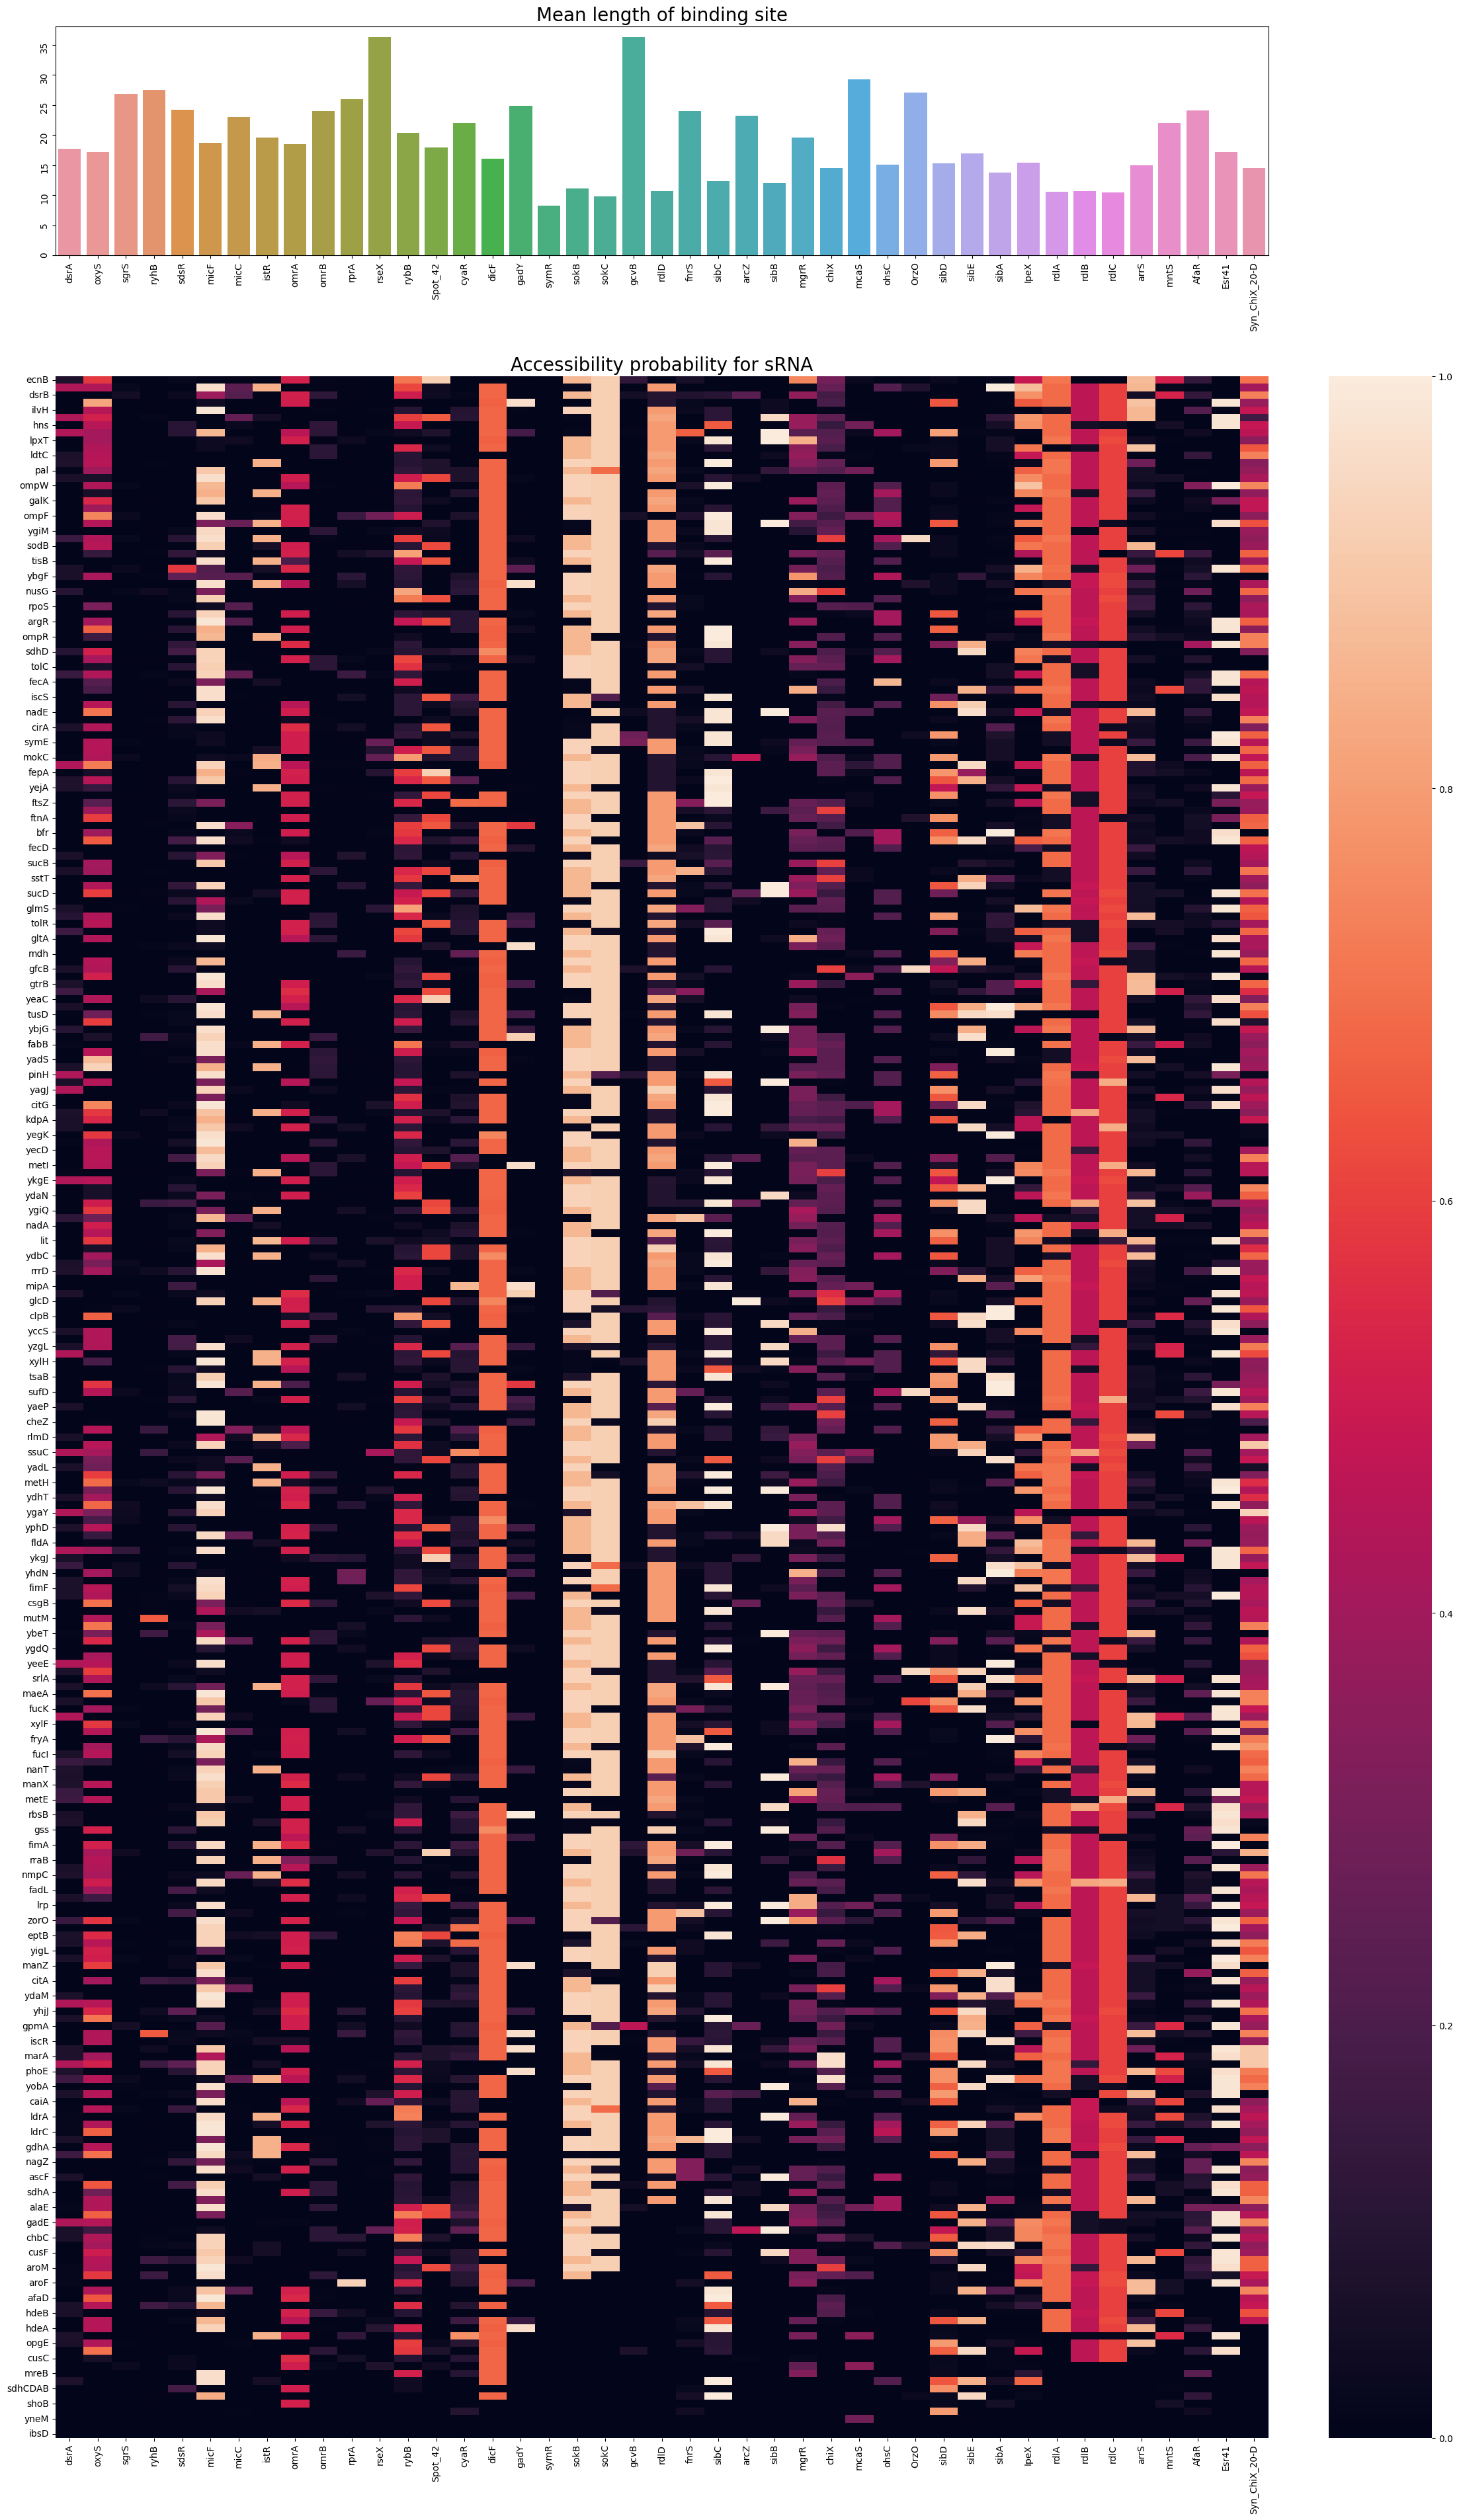

In [ ]:
fig, axs = plt.subplots(2,1,figsize=(22, 38), gridspec_kw={'height_ratios': [1, 9]}, constrained_layout=True)
fig.subplots_adjust(hspace=0.5)

sns.barplot(x=subseq.columns, y=subseq.mean(axis=0), ax=axs[0]) #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
# sns.barplot(specificity.sum(axis=0), ax=axs[0]) #, order=[l.label1._text for l in cax.ax_heatmap.get_xaxis().majorTicks])
axs[0].tick_params(rotation=90) #, labelsize=7)
axs[0].set_title('Mean length of binding site', fontsize=20)

sns.heatmap(pus2, ax=axs[1], vmin=np.min([pus1.min(), pus2.min()]), vmax=np.max([pus1.max(), pus2.max()]))
axs[1].set_title('Accessibility probability for sRNA', fontsize=20)

plt.savefig('data/figs/mRNA_official_accessibility_sRNA.jpg')



# ChiX

In [ ]:
energies[energies['chiX'] <=-10]['chiX'].sort_values(ascending=True), energies[energies['Syn_ChiX_20-D'] <= -10]['Syn_ChiX_20-D'].sort_values(ascending=True)

(eptB   -14.56
 yigL   -12.05
 fdoI   -11.70
 hokD   -11.68
 tsx    -11.53
 alaE   -11.48
 citA   -10.58
 sucC   -10.37
 rpoS   -10.34
 ygdQ   -10.32
 ompF   -10.29
 manZ   -10.14
 Name: chiX, dtype: float64,
 rpoS   -17.00
 eptB   -16.55
 mnmH   -14.70
 alaE   -14.52
 symE   -13.10
 tsx    -13.09
 yadS   -13.01
 uup    -12.85
 cycA   -12.80
 yejA   -12.44
 higB   -12.31
 rbsB   -11.95
 tusD   -11.72
 manX   -11.60
 tolR   -11.60
 shiA   -11.59
 yaiA   -11.50
 iscR   -11.28
 nmpC   -11.03
 flhD   -11.03
 mipA   -11.03
 bfr    -10.94
 mqsA   -10.67
 deoR   -10.61
 gntP   -10.49
 yqaE   -10.42
 ykgJ   -10.28
 fadL   -10.17
 trxC   -10.15
 ompN   -10.10
 Name: Syn_ChiX_20-D, dtype: float64)

In [ ]:
(specificity * energies)[(specificity * energies)['chiX'] < 0]['chiX'].sort_values(ascending=True), (specificity * energies)[(specificity * energies)['chiX'] < 0]['Syn_ChiX_20-D'].sort_values(ascending=True)

(citA   -10.58
 rpoS   -10.34
 chiP    -5.91
 chbC    -0.71
 Name: chiX, dtype: float64,
 rpoS   -0.0
 citA   -0.0
 chiP   -0.0
 chbC   -0.0
 Name: Syn_ChiX_20-D, dtype: float64)

In [ ]:
data[data['Interactor 1'] == 'chiX']

,Interactor 1,Interactor 2,ID 1,ID 2,Category 1,Category 2,Regulation,Binding position 1,Binding position 2,Sequence 1,Sequence 2,Source DB,Genome position 1,Genome position 2,Strand 1,Strand 2,Sequence before 1,Sequence before 2,Sequence after 1,Sequence after 2
234,chiX,rpoS,"chromosome:NC_000913.3, Gene ID:5061500","chromosome:NC_000913.3, Gene ID:947210",sRNA,mRNA,No Interaction,[],[],ACACCGTCGCTTAAAGTGACGGCATAATAATAAAAAAATGAAATTC...,ATGAGTCAGAATACGCTGAAAGTTCATGATTTAAATGAAGATGCGG...,sRNATarBase,507204..507287,2866559..2867551,forward,reverse,gtttcagccggatcgtgctcgtaggtatggatttgaaacgaaatct...,ATCCTCGGGTCTTGCAGGCCACACAGGACACCCTGAACCGTCATGG...,ttagcgcaacatttgcggcaaattcccttctccatacaggtgtagt...,ATCCTCGGGTCTTGCAGGCCACACAGGACACCCTGAACCGTCATGG...
290,chiX,citA,"chromosome:NC_000913.3, Gene ID:5061500","chromosome:NC_000913.3, Gene ID:945233",trans-encoded antisense RNA,mRNA,Repression,"[[46, 57]]","[[-37, -26]]",ACACCGTCGCTTAAAGTGACGGCATAATAATAAAAAAATGAAATTC...,ATGTTGCAGCTTAACGAGAATAAACAGTTTGCATTTTTCCAAAGAC...,sRNATarBase,507204..507287,652235..653893,forward,forward,gtttcagccggatcgtgctcgtaggtatggatttgaaacgaaatct...,GCCTGTGACCGACGTACTGGGGGATACGCAGATAAACTCAT,ttagcgcaacatttgcggcaaattcccttctccatacaggtgtagt...,GCCTGTGACCGACGTACTGGGGGATACGCAGATAAACTCAT
308,chiX,chiP,"chromosome:NC_000913.3, Gene ID:5061500","chromosome:NC_000913.3, Gene ID:945296",trans-encoded antisense RNA,mRNA,Repression,"[[81, 92]]","[[45, 56]]",ACACCGTCGCTTAAAGTGACGGCATAATAATAAAAAAATGAAATTC...,ATGCGTACGTTTAGTGGCAAACGTAGTACGCTGGCGCTGGCTATCG...,sRNATarBase,507204..507287,708334..709740,forward,forward,gtttcagccggatcgtgctcgtaggtatggatttgaaacgaaatct...,GCCTGTGACGGGGTCGGTTTGTACACCGATAAACTCAT,ttagcgcaacatttgcggcaaattcccttctccatacaggtgtagt...,GCCTGTGACGGGGTCGGTTTGTACACCGATAAACTCAT
341,chiX,chbC,"chromosome:NC_000913.3, Gene ID:5061500","chromosome:NC_000913.3, Gene ID:945982",trans-encoded antisense RNA,mRNA,Repression,[],[],ACACCGTCGCTTAAAGTGACGGCATAATAATAAAAAAATGAAATTC...,ATGAGTAATGTTATTGCATCGCTTGAAAAGGTACTCCTCCCTTTTG...,sRNATarBase,507204..507287,1819856..1821214,forward,reverse,gtttcagccggatcgtgctcgtaggtatggatttgaaacgaaatct...,atagaaaaatacccttaaaaaccgcaatttaaatattgcggtattg...,ttagcgcaacatttgcggcaaattcccttctccatacaggtgtagt...,ttgctgcggcaaaatcgccctgcttcgcctgtttcagtgccgcata...


In [ ]:
energies.iloc[energies.index.isin(data[data['Interactor 1'] == 'chiX']['Interactor 2'].to_list())][['chiX', 'Syn_ChiX_20-D']]

,chiX,Syn_ChiX_20-D
rpoS,-10.34,-17.00
citA,-10.58,-9.46
chiP,-5.91,-6.98
chbC,-0.71,-8.30


In [ ]:
i1 = energies[energies['chiX'] <=-10]['chiX'].sort_values(ascending=True).index.to_list()
i2 = energies[energies['Syn_ChiX_20-D'] <= -10]['Syn_ChiX_20-D'].sort_values(ascending=True).index.to_list()
i12 = set(i2).intersection(set(i1))
i12

{'alaE', 'eptB', 'rpoS', 'tsx'}

## Simulate

In [ ]:
simulate_IntaRNA_local(query={'Syn_ChiX_20-D': srnas['Syn_ChiX_20-D']}, 
                       targets={'citA': data[data['Interactor 2'] == 'citA']['Sequence before 2'].iloc[0]}, 
                       sim_kwargs=config['interaction_simulator']['simulator_kwargs'])

{'citA': {'Syn_ChiX_20-D': {'id1': 'citA',
   'id2': 'Syn_ChiX_20-D',
   'E': '-2.33',
   'E_norm': '-0.283302',
   'subseqDB': '13CGUACUGGGGGAU&43AUUCUUCUCCUUUACG',
   'Pu1': '0.000663741',
   'Pu2': '0.430109'}}}

In [ ]:
strong_binders = energies[energies['chiX'] <=-10]['chiX'].sort_values(ascending=True).index.to_list() + energies[energies['Syn_ChiX_20-D'] <= -10]['Syn_ChiX_20-D'].sort_values(ascending=True).index.to_list()
fn_s = 'data/03_simulate_sRNA_confusion/2024_01_31_171825/inter_data_raw_muts.json'

if os.path.isfile(fn_s):
    s = load_json_as_dict(fn_s)
else:
    s = simulate_IntaRNA_local(query=muts, targets={k: v for k, v in mrnas.items() if k in strong_binders}, sim_kwargs=config['interaction_simulator']['simulator_kwargs'])

    data_writer.output(data=s, out_name='inter_data_raw_muts', out_type='json')


In [ ]:
for si, v in s.items():
    if len(v) != len(muts):
        diffs = set(muts.keys()) - set(v.keys())
        for d in diffs:
            s[si][d] = default_vals
        

In [ ]:
ms = pd.DataFrame(data=np.array([[float(vv['E']) for vv in v.values()] for v in s.values()]).T,
                        columns=list(s.keys()), index=s[list(s.keys())[0]].keys())


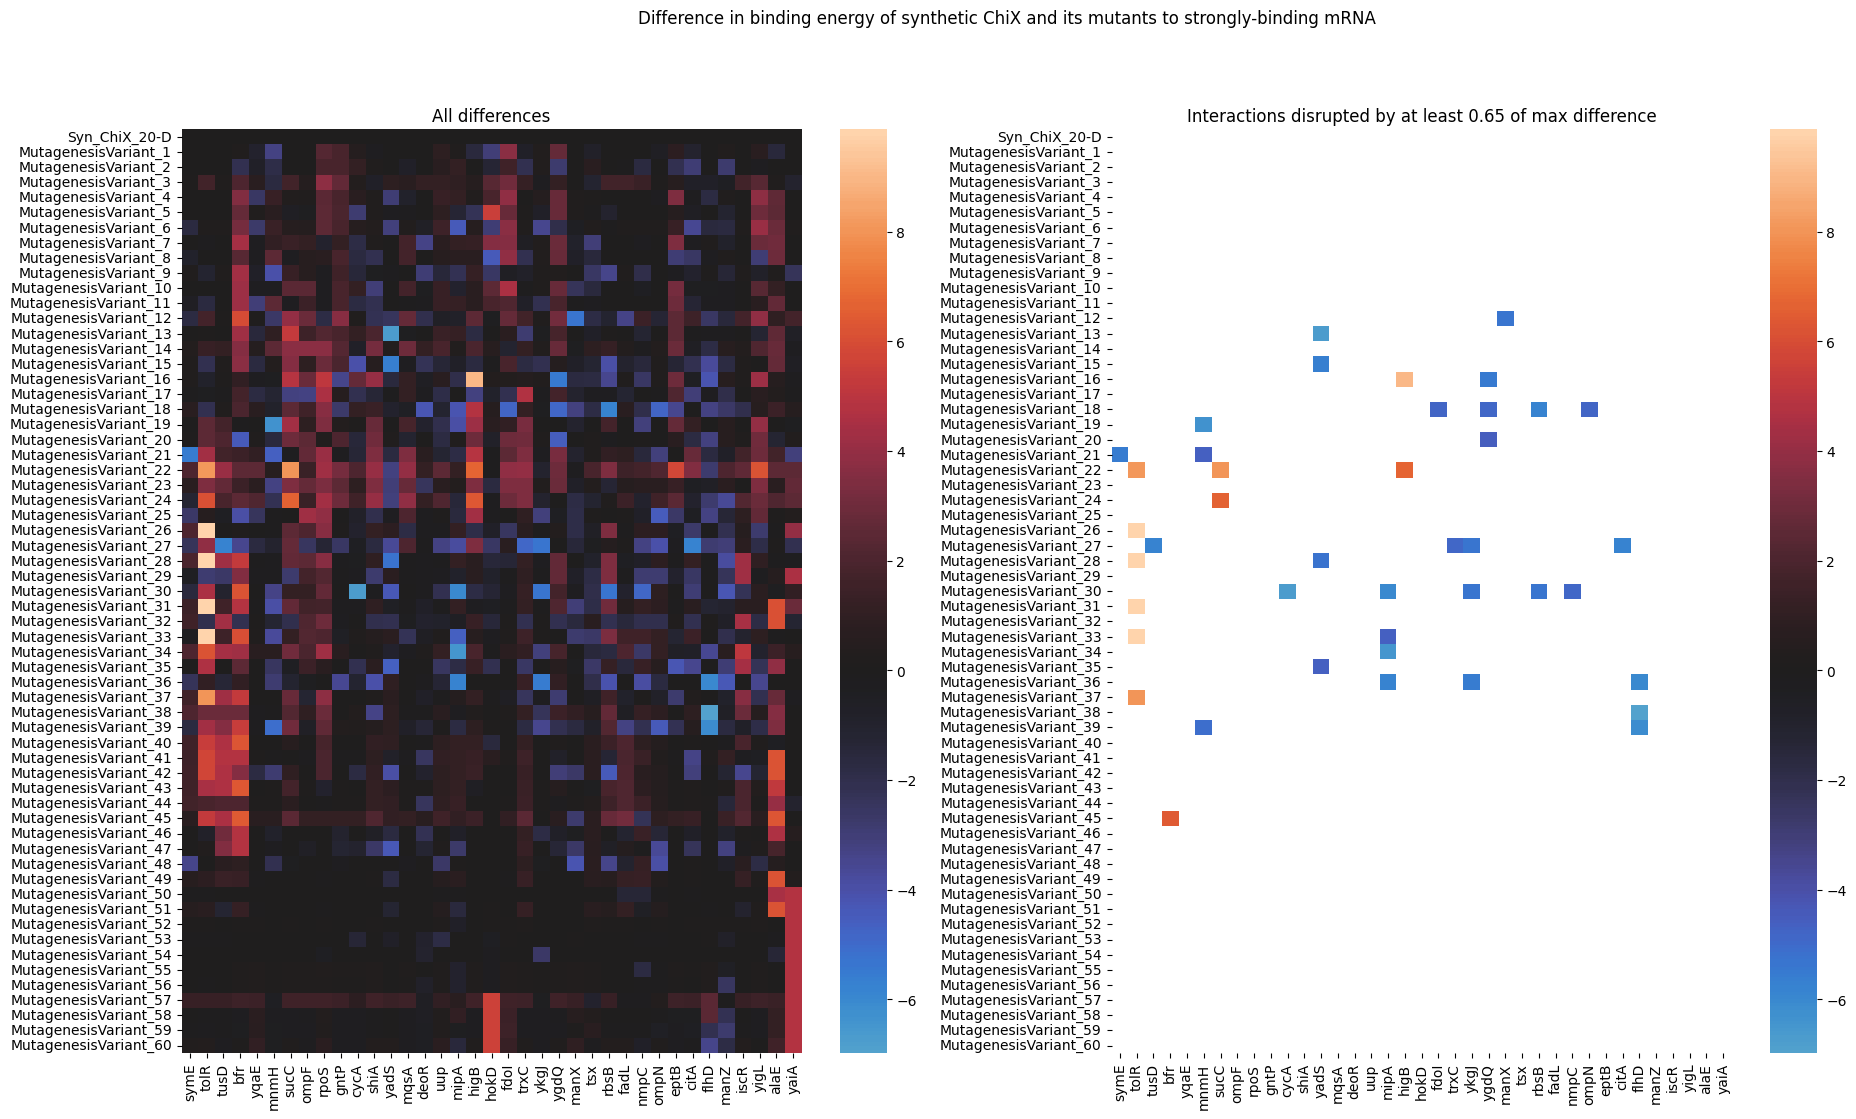

In [ ]:
fig = plt.figure(figsize=(11*2,12))
ax = plt.subplot(1,2,1)
sns.heatmap(ms - ms.iloc[0], center=0)
plt.title('All differences')
ax = plt.subplot(1,2,2)
perc = 0.65
sns.heatmap((ms - ms.iloc[0])[((ms - ms.iloc[0]) < ((ms - ms.iloc[0]).to_numpy().min() * perc)) | ((ms - ms.iloc[0]) > ((ms - ms.iloc[0]).to_numpy().max() * perc))], center=0)
plt.title(f'Interactions disrupted by at least {perc} of max difference')
plt.suptitle('Difference in binding energy of synthetic ChiX and its mutants to strongly-binding mRNA')
plt.savefig('data/figs/synchix_diffs.jpg')

In [ ]:
perc_h = 0.6
perc_l = 0.7
melted = (ms - ms.iloc[0])[((ms - ms.iloc[0]) < ((ms - ms.iloc[0]).to_numpy().min() * perc_l)) | ((ms - ms.iloc[0]) > ((ms - ms.iloc[0]).to_numpy().max() * perc_h))].melt()

melted['mutation'] = ms.index.to_list() * len(ms.columns)

melted[~melted['value'].isna()].sort_values(by='value')

,variable,value,mutation
1929,flhD,-6.98,MutagenesisVariant_38
640,cycA,-6.78,MutagenesisVariant_30
745,yadS,-6.73,MutagenesisVariant_13
1010,mipA,-6.46,MutagenesisVariant_34
324,mnmH,-6.38,MutagenesisVariant_19
1930,flhD,-6.06,MutagenesisVariant_39
1006,mipA,-6.01,MutagenesisVariant_30
1927,flhD,-6.00,MutagenesisVariant_36
149,tusD,-5.81,MutagenesisVariant_27
1012,mipA,-5.79,MutagenesisVariant_36
